# Packages

In [1]:
%load_ext rpy2.ipython

In [2]:
%%R
library(survival)
# library(survminer)
library(prodlim)
library(FSA)

R[write to console]: ## FSA v0.9.3. See citation('FSA') if used in publication.
## Run fishR() for related website and fishR('IFAR') for related book.



In [3]:
import sys
sys.path.append('/home/boscoll/github/Machine-learning-scripts')
sys.path.append('/home/boscoll/github/RNAseq-scripts')
from sklearn_surv_utils import *
from utils import *
from functions_RNAseq import * 
from survival_functions import *
from sksurv.nonparametric import kaplan_meier_estimator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline, Pipeline
import seaborn as sns
import pickle
from sksurv.metrics import concordance_index_censored, concordance_index_ipcw,cumulative_dynamic_auc
from collections import Counter
import warnings
warnings.filterwarnings("ignore")
from sksurv.svm import FastSurvivalSVM
from scipy.stats import rankdata
from scipy.stats import mannwhitneyu
from scipy.stats import fisher_exact, mannwhitneyu, chisquare, chi2_contingency
import glob
import matplotlib as mpl
import matplotlib.ticker as mtick
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = ['Helvetica']
from matplotlib import font_manager
font_manager.fontManager.addfont("/home/boscoll/Helvetica.ttc")

In [4]:
#palette ccne1 amp 
palette_ccne1 = {1:'#edb422', 0:'#004f7c'}
palette_receptors = {'HR': '#4d9221', 'HER2': '#8c2d04', 'TNBC': '#6a51a3'}

# Load data

In [5]:
ccne1_cohort = pd.read_csv('/home/boscoll/Projects/ccne1/data/4_may/ccne1_cohort.csv', index_col=0)
facets_sample_level = pd.read_csv('/home/boscoll/Projects/ccne1/data/4_may/facets_biomarkers.csv', index_col=0)
alt_matrix = pd.read_csv('/home/boscoll/Projects/ccne1/data/4_may/alt_matrix.csv', index_col=0)
primaries = pd.read_csv('/home/boscoll/Projects/ccne1/data/clinical/primaries.csv', index_col=0).drop(columns='mrn')
metastasis = pd.read_csv('/home/boscoll/Projects/ccne1/data/clinical/metastasis.csv', index_col=0)
patient_level_oncokb = pd.read_table('/home/boscoll/Projects/ccne1/data/clinical/data_clinical_patient.txt', skiprows=4, index_col=0).loc[lambda x: x.index.isin(ccne1_cohort.index.str[:9])]

In [11]:
alt_matrix.reset_index().iloc[:, 0].to_csv('/home/boscoll/Projects/ccne1/data/genomics/sample_ids.csv')

In [6]:
#sigma
sigma = pd.read_csv('/home/boscoll/Projects/ccne1/data/sigma/96matrix_output_tumortype_breast_platform_MSK-IMPACT410Genes_cf0_lite.csv', index_col=0)
sigma['categ'] = ['APOBEC' if i == "Signature_APOBEC" else 'HRD' if i in ['Signature_3_hc', 'Signature_3_lc'] else 'Clock' if i == "Signature_clock" else 'Other' for i in sigma.categ]

In [7]:
#id of patients with CCNE1 amplification by pipeline of MSK-IMPACT but not satisfying criteria for amplification by FACETS calling (tcn ≥5 without WGD or tcn ≥6 and WGD)
id_pipeline_only = pd.read_csv('/home/boscoll/Projects/ccne1/data/4_may/id_only_pipeline_samples.csv', index_col=0).index.tolist()

# Analysis

## Overall prevalence

***Size cohort***

In [8]:
ccne1_cohort['id_patient'] = ccne1_cohort.index.str[:9]
print(f'Number of samples in cohort: {ccne1_cohort.shape[0]}')
print(f'Number of patients in cohort: {ccne1_cohort.id_patient.nunique()}')

Number of samples in cohort: 6318
Number of patients in cohort: 5447


***Type of sample utilized for sequencing***

In [9]:
ccne1_cohort.sample_type.value_counts()

sample_type
Metastasis                                                                                          3591
Primary                                                                                             2494
Local Recurrence                                                                                     228
QA: Metadata ETL Update needed. Sync (Pull) REDCap into MSK Extract Builder at extract.mskcc.org       5
Name: count, dtype: int64

In [10]:
#treat local recurrence as primary, as done in RB1 paper (PMID: 41781623)
ccne1_cohort = ccne1_cohort.assign(sample_type = lambda x: ['Metastasis' if sample_type == 'Metastasis' else 'Primary' for sample_type in x.sample_type])

In [11]:
print(ccne1_cohort.sample_type.value_counts(normalize=True))
print(ccne1_cohort.sample_type.value_counts(normalize=False))

sample_type
Metastasis    0.568376
Primary       0.431624
Name: proportion, dtype: float64
sample_type
Metastasis    3591
Primary       2727
Name: count, dtype: int64


***Receptor status representation***

In [12]:
print(ccne1_cohort.receptor_status.value_counts())
print(ccne1_cohort.receptor_status.value_counts(normalize=True))

receptor_status
HR      4250
TNBC    1220
HER2     848
Name: count, dtype: int64
receptor_status
HR      0.672681
TNBC    0.193099
HER2    0.134220
Name: proportion, dtype: float64


***CCNE1 prevalence***

In [13]:
print(ccne1_cohort.ccne1_amp.value_counts(dropna=False))
print(ccne1_cohort.ccne1_amp.value_counts(normalize=True))
print(f'Number of patients with CCNE1 amplification: {ccne1_cohort.query("ccne1_amp == 1").id_patient.nunique()}')
print(f'Number of patients without CCNE1 amplification: {ccne1_cohort.query("ccne1_amp == 0").id_patient.nunique()}')

ccne1_amp
0    6067
1     251
Name: count, dtype: int64
ccne1_amp
0    0.960272
1    0.039728
Name: proportion, dtype: float64
Number of patients with CCNE1 amplification: 234
Number of patients without CCNE1 amplification: 5235


***CCNE1 prevalence across receptor***

In [14]:
(ccne1_cohort.groupby('receptor_status').ccne1_amp.value_counts(normalize=True).unstack().rename(columns = {0:'No amp', 1:'CCNE1 Amp'}) * 100).round(2).astype(str) + '%' 

ccne1_amp,No amp,CCNE1 Amp
receptor_status,,
HER2,93.28%,6.72%
HR,97.93%,2.07%
TNBC,91.31%,8.69%


In [15]:
df_stat = ccne1_cohort[['receptor_status', 'ccne1_amp']]

In [16]:
%%R -i df_stat
chisq.test(table(df_stat$receptor_status, df_stat$ccne1_amp))


	Pearson's Chi-squared test

data:  table(df_stat$receptor_status, df_stat$ccne1_amp)
X-squared = 128.22, df = 2, p-value < 2.2e-16



In [17]:
%%R -i df_stat
#her2 vs hr
non_tnbc = df_stat[df_stat$receptor_status != 'TNBC',]
non_tnbc$receptor_status = factor(non_tnbc$receptor_status, levels = c('HR', 'HER2'))
print(fisher.test(table(non_tnbc$receptor_status, non_tnbc$ccne1_amp)))

#tnbc vs hr
non_her2 = df_stat[df_stat$receptor_status != 'HER2',]
non_her2$receptor_status = factor(non_her2$receptor_status, levels = c('HR', 'TNBC'))
print(fisher.test(table(non_her2$receptor_status, non_her2$ccne1_amp)))


	Fisher's Exact Test for Count Data

data:  table(non_tnbc$receptor_status, non_tnbc$ccne1_amp)
p-value = 3.299e-11
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 2.376105 4.854254
sample estimates:
odds ratio 
  3.407009 


	Fisher's Exact Test for Count Data

data:  table(non_her2$receptor_status, non_her2$ccne1_amp)
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 3.331456 6.086704
sample estimates:
odds ratio 
  4.498659 

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


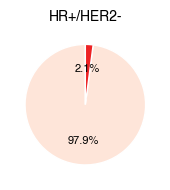

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


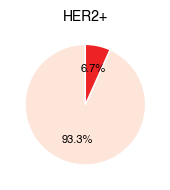

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


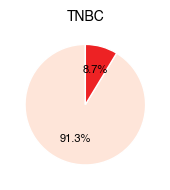

In [32]:
# hr+
pie = df_stat.query('receptor_status == "HR"')['ccne1_amp'].value_counts()
plt.figure(figsize=(4, 2))
plt.pie(pie,  colors=['#fee5d9', '#ed2224'], autopct='%.1f%%', startangle=90, textprops={'fontsize': 8}, wedgeprops={'edgecolor': 'white'})
plt.title('HR+/HER2-', fontsize=10)
plt.tight_layout()
plt.savefig('/home/boscoll/Projects/ccne1/results/figures/pie_hr_pos.pdf')
plt.show()

# her2+
pie = df_stat.query('receptor_status == "HER2"')['ccne1_amp'].value_counts()
plt.figure(figsize=(4, 2))
plt.pie(pie,  colors=['#fee5d9', '#ed2224'], autopct='%.1f%%', startangle=90, textprops={'fontsize': 8}, wedgeprops={'edgecolor': 'white'})
plt.title('HER2+', fontsize=10)
plt.tight_layout()
plt.savefig('/home/boscoll/Projects/ccne1/results/figures/pie_her2_pos.pdf')
plt.show()

# tnbc 
pie = df_stat.query('receptor_status == "TNBC"')['ccne1_amp'].value_counts()
plt.figure(figsize=(4, 2))
plt.pie(pie,  colors=['#fee5d9', '#ed2224'], autopct='%.1f%%', startangle=90, textprops={'fontsize': 8}, wedgeprops={'edgecolor': 'white'})
plt.title('TNBC', fontsize=10)
plt.tight_layout()
plt.savefig('/home/boscoll/Projects/ccne1/results/figures/pie_tnbc.pdf')
plt.show()



***Characteristics CCNE1 amplifications - size and degree***

In [18]:
df_stats = ccne1_cohort.query('ccne1_amp == 1')

In [19]:
print(df_stats.tcn_em.describe())

count    251.000000
mean       9.613546
std        7.589865
min        2.000000
25%        6.000000
50%        6.000000
75%       10.000000
max       65.000000
Name: tcn_em, dtype: float64


In [20]:
#amplification size
df_stats.seg_length.describe() / 1000000

count     0.000251
mean     11.546396
std      11.212414
min       0.009986
25%       2.684459
50%       9.768386
75%      16.600176
max      57.889459
Name: seg_length, dtype: float64

In [21]:
#nr focal and non focal CCNE1 amplifications
print(df_stats.focal_amp.value_counts(normalize=True))
print(df_stats.focal_amp.value_counts())

focal_amp
focal        0.501992
non-focal    0.498008
Name: proportion, dtype: float64
focal_amp
focal        126
non-focal    125
Name: count, dtype: int64


In [22]:
%%R -i df_stats
#correlation tcn_em and seg_length
cor.test(df_stats$tcn_em, df_stats$seg_length, method = 'spearman')


	Spearman's rank correlation rho

data:  df_stats$tcn_em and df_stats$seg_length
S = 4029118, p-value < 2.2e-16
alternative hypothesis: true rho is not equal to 0
sample estimates:
       rho 
-0.5287871 



In [28]:
df_stats.seg_length.describe() 

count    2.510000e+02
mean     1.154640e+07
std      1.121241e+07
min      9.986000e+03
25%      2.684460e+06
50%      9.768386e+06
75%      1.660018e+07
max      5.788946e+07
Name: seg_length, dtype: float64

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


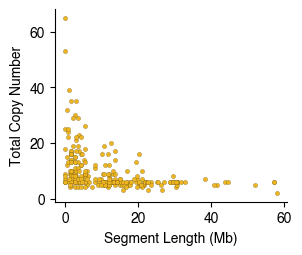

In [40]:
#scatterplot segment size and tcn_em
plt.figure(figsize=(3, 2.5))
sns.scatterplot(data=df_stats.assign(seg_length = lambda x: x['seg_length'] / 1e6), x='seg_length', y='tcn_em', color='#ecb421', edgecolor='black', linewidth=0.1, s=10)
plt.xlabel('Segment Length (Mb)', fontsize=10)
plt.ylabel('Total Copy Number', fontsize=10)
# plt.title('CCNE1 Amplified Samples', fontsize=12)
sns.despine()
plt.savefig('/home/boscoll/Projects/ccne1/results/figures/fig_1/scatter_seg_length_tcn_em.pdf', bbox_inches='tight')
plt.show()

In [41]:
#tcn in focal vs non focal
df_stats.groupby('focal_amp')['tcn_em'].describe()

,count,mean,std,min,25%,50%,75%,max
focal_amp,,,,,,,,
focal,126.0,12.47619,9.470556,4.0,6.0,9.0,15.75,65.0
non-focal,125.0,6.72800,3.001011,2.0,5.0,6.0,6.00,20.0


In [42]:
%%R -i df_stats
wilcox.test(df_stats$tcn_em ~ df_stats$focal_amp)


	Wilcoxon rank sum test with continuity correction

data:  df_stats$tcn_em by df_stats$focal_amp
W = 12141, p-value = 3.96e-14
alternative hypothesis: true location shift is not equal to 0



In [43]:
%%R -i df_stats
#correcting for WGD
res = lm(tcn_em ~ seg_length + wgd, data = df_stats)
summary(res)


Call:
lm(formula = tcn_em ~ seg_length + wgd, data = df_stats)

Residuals:
   Min     1Q Median     3Q    Max 
-8.467 -4.027 -1.850  1.275 52.932 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.207e+01  8.426e-01  14.326  < 2e-16 ***
seg_length  -2.539e-07  3.998e-08  -6.349 1.03e-09 ***
wgdTRUE      7.523e-01  9.264e-01   0.812    0.418    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 7.066 on 248 degrees of freedom
Multiple R-squared:  0.1401,	Adjusted R-squared:  0.1332 
F-statistic:  20.2 on 2 and 248 DF,  p-value: 7.431e-09



1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


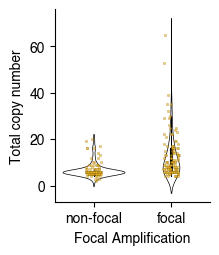

In [54]:
#boxplot of tcn_em by receptor status
plt.figure(figsize=(2,2.5))
sns.violinplot(data=df_stats, x='focal_amp', y='tcn_em', color = 'white', linewidth=0.5, edgecolor='black')
sns.stripplot(data=df_stats, x='focal_amp', y='tcn_em',  alpha=0.6, size=2, color = "#ecb421", edgecolor='black', linewidth=0.1)
plt.xlabel('Focal Amplification')
plt.ylabel('Total copy number')
sns.despine()
plt.savefig('/home/boscoll/Projects/ccne1/results/figures/fig_1/violin_focal_amp_tcn_em.pdf', bbox_inches='tight')
plt.show()

***Degree of amplification according to receptor status***

In [22]:
df_stats = ccne1_cohort.query('ccne1_amp == 1')
df_stats.groupby('receptor_status')['tcn_em'].describe()

,count,mean,std,min,25%,50%,75%,max
receptor_status,,,,,,,,
HER2,57.0,11.070175,7.957161,3.0,6.0,8.0,14.0,39.0
HR,88.0,8.795455,8.958601,2.0,6.0,6.0,8.0,65.0
TNBC,106.0,9.509434,5.930141,3.0,6.0,7.0,12.0,32.0


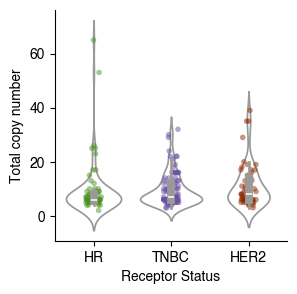

In [59]:
#boxplot of tcn_em by receptor status
plt.figure(figsize=(3,3))
sns.violinplot(data=df_stats, x='receptor_status', y='tcn_em', color='white', width=0.8, zorder = 0)
sns.stripplot(data=df_stats, x='receptor_status', y='tcn_em', palette=palette_receptors, alpha=0.5, zorder = 1, size = 4)
plt.xlabel('Receptor Status')
plt.ylabel('Total copy number')
sns.despine()
# plt.savefig('/home/boscoll/Projects/ccne1/results/figures/tcn_em_by_receptor_status.pdf', bbox_inches='tight')
plt.show()

In [60]:
%%R -i df_stats
print(kruskal.test(tcn_em ~ receptor_status, data = df_stats))
#dunn test
print(dunnTest(tcn_em ~ receptor_status, data = df_stats, method = "bh"))


	Kruskal-Wallis rank sum test

data:  tcn_em by receptor_status
Kruskal-Wallis chi-squared = 8.2228, df = 2, p-value = 0.01638



R[write to console]:   Kruskal-Wallis rank sum test

data: x and g

R[write to console]: Kruskal-Wallis chi-squared = 8.2228, df = 2, p-value = 0.02


R[write to console]: 

R[write to console]:                      Dunn's Pairwise Comparison of x by g                     

R[write to console]:                              (Benjamini-Hochberg)                             

R[write to console]: Col Mean-│

R[write to console]: Row Mean │       HER2         HR

R[write to console]: ─────────┼──────────────────────

R[write to console]:       HR │   2.763750

R[write to console]:          │     0.0171*

R[write to console]:          │

R[write to console]:     TNBC │   1.141432  -1.958336

R[write to console]:          │     0.2537     0.0753 

R[write to console]: 

R[write to console]: FDR = 0.05

R[write to console]: Reject Ho if p ≤ FDR with stopping rule, where p = Pr(|Z| ≥ |z|)

R[write to console]: Dunn (1964) Kruskal-Wallis multiple comparison

R[write to console]:   p-values adju

   Comparison         Z     P.unadj      P.adj
1   HER2 - HR  2.763750 0.005714128 0.01714238
2 HER2 - TNBC  1.141432 0.253690182 0.25369018
3   HR - TNBC -1.958337 0.050190483 0.07528572


***Degree of amplification and focality of the gain across receptors***

In [23]:
df_stats = ccne1_cohort.query('ccne1_amp == 1')

In [24]:
#focal amplification and receptor status
pd.crosstab(df_stats.focal_amp, df_stats.receptor_status, normalize='columns').round(3)

receptor_status,HER2,HR,TNBC
focal_amp,,,
focal,0.544,0.42,0.547
non-focal,0.456,0.58,0.453


In [64]:
%%R -i df_stats
chisq.test(table(df_stats$focal_amp, df_stats$receptor_status))


	Pearson's Chi-squared test

data:  table(df_stats$focal_amp, df_stats$receptor_status)
X-squared = 3.6053, df = 2, p-value = 0.1649



***CCNE1 in primary vs metastatic samples***

In [96]:
(ccne1_cohort.groupby('sample_type').ccne1_amp.value_counts(normalize=True).unstack().rename(columns = {0:'No amp', 1:'CCNE1 Amp'}) * 100).round(2).astype(str) + '%'

ccne1_amp,No amp,CCNE1 Amp
sample_type,,
Primary,95.45%,4.55%
Metastasis,96.46%,3.54%


In [97]:
%%R -i ccne1_cohort
chisq.test(table(ccne1_cohort$ccne1_amp, ccne1_cohort$sample_type))


	Pearson's Chi-squared test with Yates' continuity correction

data:  table(ccne1_cohort$ccne1_amp, ccne1_cohort$sample_type)
X-squared = 3.888, df = 1, p-value = 0.04863



***CCNE1 prevalence according to treatment exposure***

In [25]:
df_stats = ccne1_cohort.copy()
df_stats = df_stats.assign(group = ['treatment_naive' if x == "Primary Treatment Naive" else 'non_naive' for x in df_stats.sample_type_detailed])

In [26]:
(df_stats.groupby('group').ccne1_amp.value_counts(normalize=True).unstack().rename(columns = {0:'No amp', 1:'CCNE1 Amp'}) * 100).round(2).astype(str) + '%'

ccne1_amp,No amp,CCNE1 Amp
group,,
non_naive,96.26%,3.74%
treatment_naive,95.66%,4.34%


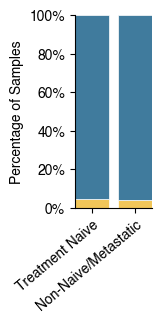

In [12]:
plt.figure(figsize=(1, 2.5))
df_stats['group'] = pd.Categorical(df_stats['group'], categories=['treatment_naive', 'non_naive'], ordered=True)
sns.histplot(data=df_stats, x='group', hue='ccne1_amp', multiple='fill', palette=palette_ccne1, edgecolor='white', linewidth=0.5, shrink=0.8, legend=False)
sns.despine()
plt.xticks([0,1], ['Treatment Naive', 'Non-Naive/Metastatic'], rotation=40, ha='right', rotation_mode='anchor')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xlabel('')
plt.ylabel('Percentage of Samples')
# plt.savefig('/home/boscoll/Projects/ccne1/results/figures/fig_2/bar_ccne1_amp_by_sample_type.pdf', bbox_inches='tight')
plt.show()

In [ ]:
%%R -i df_stats
chisq.test(table(df_stats$group, df_stats$ccne1_amp))


	Pearson's Chi-squared test with Yates' continuity correction

data:  table(df_stats$group, df_stats$ccne1_amp)
X-squared = 1.2596, df = 1, p-value = 0.2617



In [52]:
#copy number state CCNE1 according to treatment 
ccne1_cohort.query('ccne1_amp ==1').assign(group = lambda x: ['treatment_naive' if y == "Primary Treatment Naive" else 'non_naive' for y in x.sample_type_detailed]).groupby('group').tcn_em.describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
non_naive,145.0,9.855172,8.512229,3.0,6.0,6.0,10.0,65.0
treatment_naive,106.0,9.283019,6.131503,2.0,6.0,6.5,11.0,32.0


***CCNE1 focal gain according to treatment exposure***

In [27]:
(df_stats.query("ccne1_amp == 1").groupby('group')['focal_amp'].value_counts(normalize=True).unstack() * 100).round(2).astype(str) + '%'

focal_amp,focal,non-focal
group,,
non_naive,54.48%,45.52%
treatment_naive,44.34%,55.66%


In [28]:
%%R -i df_stats
df_stats$group = factor(df_stats$group, levels = c('treatment_naive', 'non_naive'))
fisher.test(table(df_stats$focal_amp, df_stats$group))


	Fisher's Exact Test for Count Data

data:  table(df_stats$focal_amp, df_stats$group)
p-value = 0.0004847
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.4938373 0.8293699
sample estimates:
odds ratio 
 0.6421282 



In [28]:
%%R -i df_stats
hr_pos = df_stats[df_stats$receptor_status == 'HR',]
print(fisher.test(table(hr_pos$focal_amp, hr_pos$group)))
table(hr_pos$focal_amp, hr_pos$group)


	Fisher's Exact Test for Count Data

data:  table(hr_pos$focal_amp, hr_pos$group)
p-value = 0.009138
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.3888837 0.8938002
sample estimates:
odds ratio 
 0.5953315 

           
            treatment_naive non_naive
  focal                  35        90
  non-focal            1630      2495


In [29]:
%%R -i df_stats
her2_pos = df_stats[df_stats$receptor_status == 'HER2',]
print(fisher.test(table(her2_pos$focal_amp, her2_pos$group)))
table(her2_pos$focal_amp, her2_pos$group)


	Fisher's Exact Test for Count Data

data:  table(her2_pos$focal_amp, her2_pos$group)
p-value = 0.002209
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.2249752 0.7570984
sample estimates:
odds ratio 
 0.4223501 

           
            treatment_naive non_naive
  focal                  17        53
  non-focal             336       442


In [30]:
%%R -i df_stats
tnbc = df_stats[df_stats$receptor_status == 'TNBC',]
print(fisher.test(table(tnbc$focal_amp, tnbc$group)))
table(tnbc$focal_amp, tnbc$group)


	Fisher's Exact Test for Count Data

data:  table(tnbc$focal_amp, tnbc$group)
p-value = 0.8362
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.6107481 1.4469068
sample estimates:
odds ratio 
 0.9464277 

           
            treatment_naive non_naive
  focal                  38        75
  non-focal             386       721


***CCNE1 amplifications across treatment exposures across receptors subtypes***

In [20]:
(df_stats.query('receptor_status == "HR"').groupby('group').ccne1_amp.value_counts(normalize=True).unstack().rename(columns = {0:'No amp', 1:'CCNE1 Amp'}) * 100).round(2).astype(str) + '%'

ccne1_amp,No amp,CCNE1 Amp
group,,
treatment_naive,97.66%,2.34%
non_naive,98.1%,1.9%


In [21]:
%%R -i df_stats
hr_pos = df_stats[df_stats$receptor_status == 'HR',]
fisher.test(table(hr_pos$group, hr_pos$ccne1_amp))


	Fisher's Exact Test for Count Data

data:  table(hr_pos$group, hr_pos$ccne1_amp)
p-value = 0.3225
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.5156309 1.2661684
sample estimates:
odds ratio 
 0.8056194 



In [17]:
(df_stats.query('receptor_status == "HER2"').groupby('group').ccne1_amp.value_counts(normalize=True).unstack().rename(columns = {0:'No amp', 1:'CCNE1 Amp'}) * 100).round(2).astype(str) + '%'

ccne1_amp,No amp,CCNE1 Amp
group,,
treatment_naive,94.33%,5.67%
non_naive,92.53%,7.47%


In [22]:
%%R -i df_stats
her2_pos = df_stats[df_stats$receptor_status == 'HER2',]
fisher.test(table(her2_pos$group, her2_pos$ccne1_amp))


	Fisher's Exact Test for Count Data

data:  table(her2_pos$group, her2_pos$ccne1_amp)
p-value = 0.3321
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.7449419 2.4921106
sample estimates:
odds ratio 
  1.344628 



In [18]:
(df_stats.query('receptor_status == "TNBC"').groupby('group').ccne1_amp.value_counts(normalize=True).unstack().rename(columns = {0:'No amp', 1:'CCNE1 Amp'}) * 100).round(2).astype(str) + '%'

ccne1_amp,No amp,CCNE1 Amp
group,,
treatment_naive,88.92%,11.08%
non_naive,92.59%,7.41%


In [23]:
%%R -i df_stats
tnbc = df_stats[df_stats$receptor_status == 'TNBC',]
fisher.test(table(tnbc$group, tnbc$ccne1_amp))


	Fisher's Exact Test for Count Data

data:  table(tnbc$group, tnbc$ccne1_amp)
p-value = 0.03295
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.4213406 0.9836701
sample estimates:
odds ratio 
   0.64236 



***CCNE1 prevalence across histologies***

In [29]:
df_stats = ccne1_cohort.join(primaries[['histology']]).assign(histology_sample = lambda x: ['Lobular' if i == "Mammary - No Subtype" and j == "ILC" else i for i, j in zip(x.histology_sample, x.histology)])

In [30]:
#prevalence among lobular
df_stats.query('histology_sample == "Lobular"').ccne1_amp.value_counts().rename(index={0:'No amp', 1:'CCNE1 Amp'})

ccne1_amp
No amp       624
CCNE1 Amp      6
Name: count, dtype: int64

In [129]:
df_stats.histology_sample.value_counts()

histology_sample
Ductal                    2780
Mammary - No Subtype      2704
Lobular                    630
Other Breast (specify)     101
Mixed                       85
No Info                     12
Non-Breast (specify)         6
Name: count, dtype: int64

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


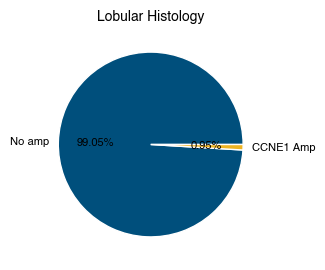

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


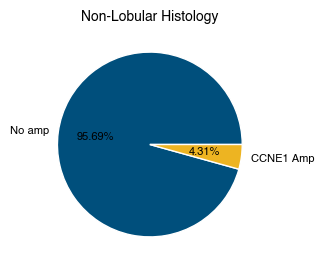

In [149]:
plt.figure(figsize=(3, 3))
df_stats.query('histology_sample == "Lobular"')[['ccne1_amp']].value_counts().plot.pie(autopct='%.2f%%', colors=['#004f7c', '#edb422'], wedgeprops={'edgecolor': 'white'}, textprops={'fontsize': 8}, labels = ['No amp', 'CCNE1 Amp'])
plt.ylabel('')
plt.title('Lobular Histology', fontsize=10, fontweight='bold')
plt.savefig('/home/boscoll/Projects/ccne1/results/figures/pie_lobular.pdf', bbox_inches='tight')
plt.show()

plt.figure(figsize=(3, 3))
df_stats.query('histology_sample != "Lobular"')[['ccne1_amp']].value_counts().plot.pie(autopct='%.2f%%', colors=['#004f7c', '#edb422'], wedgeprops={'edgecolor': 'white'}, textprops={'fontsize': 8}, labels = ['No amp', 'CCNE1 Amp'])
plt.ylabel('')
plt.title('Non-Lobular Histology', fontsize=10, fontweight='bold')
plt.savefig('/home/boscoll/Projects/ccne1/results/figures/pie_non_lobular.pdf', bbox_inches='tight')
plt.show()

In [11]:
df_stats = df_stats.assign(histology_sample = lambda x: ['Lobular' if histology == 'Lobular' else 'Other' for histology in x.histology_sample])

In [18]:
df_stats.query('histology_sample == "Other"').ccne1_amp.value_counts().rename(index={0:'No amp', 1:'CCNE1 Amp'}).to_frame().assign(prev = lambda x: x / len(df_stats.query('histology_sample == "Other"'))).round(3)

,count,prev
ccne1_amp,,
No amp,5443,0.957
CCNE1 Amp,245,0.043


In [82]:
%%R -i df_stats
df_stats$histology_sample = factor(df_stats$histology_sample, levels = c( "Other", "Lobular"))
fisher.test(table(df_stats$histology_sample, df_stats$ccne1_amp))


	Fisher's Exact Test for Count Data

data:  table(df_stats$histology_sample, df_stats$ccne1_amp)
p-value = 4.263e-06
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.07731571 0.47467628
sample estimates:
odds ratio 
 0.2136482 



# Clinical associations

In [31]:
primaries = primaries.merge(ccne1_cohort[['ccne1_amp']], left_index=True, right_index=True)
id_ccne1_amp = ccne1_cohort.query('ccne1_amp == 1')[['record_id']]
metastasis['ccne1_amp'] = metastasis.record_id.isin(id_ccne1_amp.record_id).astype(int)
primaries['focal_amp'] = primaries.index.isin(ccne1_cohort.loc[ccne1_cohort.focal_amp == 'focal'].index).astype(int)

***Age***

In [32]:
print(primaries.groupby('ccne1_amp').age_at_dx.describe())

            count       mean        std   min   25%   50%   75%   max
ccne1_amp                                                            
0          5026.0  51.060485  12.265858   8.0  42.0  50.0  60.0  93.0
1           212.0  50.778302  11.672177  29.0  43.0  51.0  58.0  92.0


***Histologic grade***

In [232]:
df_stats = primaries.query('histologic_grade not in ["No Info", "Unk."]')
print(f'Samples with available histologic grade: {df_stats.shape[0]}')
(df_stats.groupby('ccne1_amp').histologic_grade.value_counts(normalize=True).unstack() * 100).round(2).astype(str) + '%'

Samples with available histologic grade: 4571


histologic_grade,High,Int.,Low
ccne1_amp,,,
0,65.12%,31.0%,3.88%
1,85.26%,14.74%,nan%


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


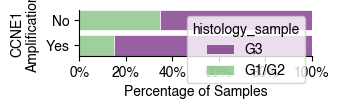

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


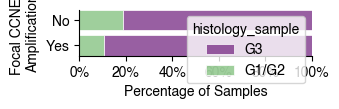

In [ ]:
plt.figure(figsize=(3, 0.6))
df_plot = df_stats.query('histology_sample not in ["No Info", "Unknown"]').copy()
df_plot['histology_sample'] = ['G3' if histologic_grade == 'High' else 'G1/G2' for histologic_grade in df_plot.histologic_grade]
df_plot['histology_sample'] = pd.Categorical(df_plot['histology_sample'], categories=['G3', 'G1/G2'], ordered=True)
df_plot = df_plot.sort_values('histology_sample')
sns.histplot(data=df_plot.assign(ccne1_amp = lambda x: x.ccne1_amp.astype(str)), multiple='fill', palette = {'G1/G2': '#7fbf7b', 'G3': '#762a83'}, y='ccne1_amp', hue='histology_sample', edgecolor='white', linewidth=0.5, shrink = 0.8, legend=True)
sns.despine()
plt.ylabel('CCNE1\nAmplification')
plt.yticks([0,1], ['No', 'Yes'])
plt.xlabel('Percentage of Samples')
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
# plt.savefig('/home/boscoll/Projects/ccne1/results/figures/fig_2/bar_ccne1_amp_by_histologic_grade.pdf', bbox_inches='tight')
plt.show()

plt.figure(figsize=(3, 0.6))
df_plot = df_stats.query('histology_sample not in ["No Info", "Unknown"] and ccne1_amp == 1').copy()
df_plot['histology_sample'] = ['G3' if histologic_grade == 'High' else 'G1/G2' for histologic_grade in df_plot.histologic_grade]
df_plot['histology_sample'] = pd.Categorical(df_plot['histology_sample'], categories=['G3', 'G1/G2'], ordered=True)
df_plot = df_plot.sort_values('histology_sample')
df_plot['focal_amp'] = pd.Categorical(df_plot['focal_amp'], categories=[0,1], ordered=True)
df_plot = df_plot.sort_values('focal_amp')
sns.histplot(data=df_plot, multiple='fill', palette = {'G1/G2': '#7fbf7b', 'G3': '#762a83'}, y='focal_amp', hue='histology_sample', edgecolor='white', linewidth=0.5, shrink = 0.8, legend=True)
sns.despine()
plt.ylabel('Focal CCNE1\nAmplification')
plt.yticks([0,1], ['No', 'Yes'])
plt.xlabel('Percentage of Samples')
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
# plt.savefig('/home/boscoll/Projects/ccne1/results/figures/fig_2/bar_ccne1_amp_by_focal_amp.pdf', bbox_inches='tight')
plt.show()


In [235]:
%%R -i df_stats
df_stats$histologic_grade = ifelse(df_stats$histologic_grade == "High", "high", "low/med")
df_stats$histologic_grade = factor(df_stats$histologic_grade, levels = c("low/med", "high"))
df_stats$ccne1_amp = factor(df_stats$ccne1_amp, levels = c(0, 1))
fisher.test(table(df_stats$ccne1_amp, df_stats$histologic_grade))


	Fisher's Exact Test for Count Data

data:  table(df_stats$ccne1_amp, df_stats$histologic_grade)
p-value = 1.542e-09
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 2.053747 4.831506
sample estimates:
odds ratio 
  3.098067 



***Histologic grade according to focal or non focal amp***

In [ ]:
(df_stats.query('ccne1_amp == 1').groupby('focal_amp').histologic_grade.value_counts(normalize=True).unstack() * 100).round(2).astype(str) + '%'

histologic_grade,High,Int.
focal_amp,,
0,81.05%,18.95%
1,89.47%,10.53%


In [100]:
%%R -i df_stats
df_stats = df_stats[df_stats$ccne1_amp == 1, ]
df_stats$histologic_grade = ifelse(df_stats$histologic_grade == "High", 1, 0)
fisher.test(table(df_stats$focal_amp, df_stats$histologic_grade))


	Fisher's Exact Test for Count Data

data:  table(df_stats$focal_amp, df_stats$histologic_grade)
p-value = 0.1511
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.8083448 5.1145822
sample estimates:
odds ratio 
  1.979939 



***Histologic grade among HR+/HER2-***

In [110]:
(df_stats.query('receptor_status == "HR"').groupby('ccne1_amp').histologic_grade.value_counts(normalize=True).unstack() * 100).round(2).astype(str) + '%'

histologic_grade,High,Int.,Low
ccne1_amp,,,
0,57.09%,37.94%,4.96%
1,77.14%,22.86%,nan%


In [106]:
%%R -i df_stats
df_stats = df_stats[df_stats$receptor_status == "HR",]
df_stats$histologic_grade = ifelse(df_stats$histologic_grade == "High", 1, 0)
fisher.test(table(df_stats$ccne1_amp, df_stats$histologic_grade))


	Fisher's Exact Test for Count Data

data:  table(df_stats$ccne1_amp, df_stats$histologic_grade)
p-value = 0.0008304
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 1.421644 4.769332
sample estimates:
odds ratio 
  2.535476 



***PgR in HR+/HER2-***

In [34]:
df_stats =  primaries.query('receptor_status == "HR" and pr not in ["No Info", "Unk."]')

In [35]:
(df_stats.groupby('ccne1_amp').pr.value_counts(normalize=True).unstack().round(4).rename(index = {0:'No amp', 1:'CCNE1 Amp'}) * 100).round(2).astype(str) + '%'

pr,+,Neg.
ccne1_amp,,
No amp,84.78%,15.22%
CCNE1 Amp,72.97%,27.03%


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


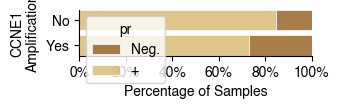

In [ ]:
plt.figure(figsize=(3, 0.6))
df_plot = df_stats.query('pr != "Unk."').copy()
df_plot['pr'] = pd.Categorical(df_plot['pr'], categories=['Neg.', '+'], ordered=True)
sns.histplot(data=df_plot.assign(ccne1_amp = lambda x: x.ccne1_amp.astype(str)), y='ccne1_amp', hue='pr', multiple='fill', palette = {'Neg.': '#8c510a', '+': '#d8b365'}, edgecolor='white', linewidth=0.5, shrink=0.8, legend=True)
sns.despine()
plt.yticks([0,1], ['No', 'Yes'])
plt.xlabel('Percentage of Samples')
plt.ylabel('CCNE1\nAmplification')
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
# plt.savefig('/home/boscoll/Projects/ccne1/results/figures/fig_2/bar_ccne1_amp_by_pr.pdf', bbox_inches='tight')
plt.show()

In [74]:
%%R -i df_stats
fisher.test(table(df_stats$ccne1_amp, df_stats$pr))


	Fisher's Exact Test for Count Data

data:  table(df_stats$ccne1_amp, df_stats$pr)
p-value = 0.008818
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 1.158619 3.538753
sample estimates:
odds ratio 
  2.062323 



***PgR in HR+/HER2- according to focal gain***

In [36]:
df_stats =  primaries.query('receptor_status == "HR" and pr not in ["No Info", "Unk."]')
(df_stats.query('ccne1_amp == 1').groupby('focal_amp')['pr'].value_counts(normalize=True).unstack().round(4).rename(index = {0:'non focal', 1:'focal amp'}) * 100).round(2).astype(str) + '%'

pr,+,Neg.
focal_amp,,
non focal,79.55%,20.45%
focal amp,63.33%,36.67%


In [76]:
%%R -i df_stats
fisher.test(table(df_stats$focal_amp, df_stats$pr))


	Fisher's Exact Test for Count Data

data:  table(df_stats$focal_amp, df_stats$pr)
p-value = 0.002901
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 1.269295 3.446949
sample estimates:
odds ratio 
  2.121398 



***ER levels***

In [37]:
df_stats = primaries.query('receptor_status == "HR" and `er_%_primary`.notnull()')
df_stats = df_stats.assign(er_low = lambda x: [1 if i <= 10 else 0 for i in x['er_%_primary']])
df_stats.groupby('ccne1_amp')['er_%_primary'].describe()

,count,mean,std,min,25%,50%,75%,max
ccne1_amp,,,,,,,,
0,2954.0,82.638118,26.396545,0.0,80.0,95.0,98.75,100.0
1,71.0,60.985915,38.658391,0.0,15.0,80.0,95.00,100.0


In [205]:
print(f'nr tumors {df_stats.groupby("ccne1_amp").size().sum()}, of which ccne1 amplified {df_stats.groupby("ccne1_amp").size()[1]}')
print(df_stats.groupby('ccne1_amp').er_low.value_counts(normalize=False).unstack())
(df_stats.groupby('ccne1_amp').er_low.value_counts(normalize=True).unstack() * 100).round(2).astype(str) + '%'

nr tumors 3025, of which ccne1 amplified 71
er_low        0    1
ccne1_amp           
0          2761  193
1            53   18


er_low,0,1
ccne1_amp,,
0,93.47%,6.53%
1,74.65%,25.35%


In [206]:
%%R -i df_stats
fisher.test(table(df_stats$ccne1_amp, df_stats$er_low))


	Fisher's Exact Test for Count Data

data:  table(df_stats$ccne1_amp, df_stats$er_low)
p-value = 8.436e-07
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 2.621944 8.618019
sample estimates:
odds ratio 
  4.853824 



1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


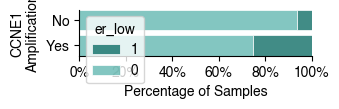

In [ ]:
plt.figure(figsize=(3, 0.6))
df_plot = df_stats.copy()
df_plot['er_low'] = pd.Categorical(df_plot['er_low'], categories=[1, 0], ordered=True)
df_plot = df_plot.sort_values('er_low')
sns.histplot(data=df_plot.assign(ccne1_amp = lambda x: x.ccne1_amp.astype(str)), y='ccne1_amp', hue='er_low', multiple='fill', palette = {0: '#5ab4ac', 1: '#01665e'}, edgecolor='white', linewidth=0.5, shrink=0.8, legend=True)
sns.despine()
plt.yticks([0,1], ['No', 'Yes'])
plt.xlabel('Percentage of Samples')
plt.ylabel('CCNE1\nAmplification')
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
# plt.savefig('/home/boscoll/Projects/ccne1/results/figures/fig_2/bar_ccne1_amp_by_erlow.pdf', bbox_inches='tight')
plt.show()

***Er% according to focal or non focal amplification***

In [77]:
df_stats.query('ccne1_amp == 1').groupby('focal_amp')['er_%_primary'].describe()

,count,mean,std,min,25%,50%,75%,max
focal_amp,,,,,,,,
0,43.0,66.372093,38.284663,0.0,55.0,80.0,95.0,100.0
1,28.0,52.714286,38.436920,0.0,10.0,60.0,90.0,100.0


## Genomic alterations

In [40]:
#logistic regression between alterations using ccne1 amp and corrected for receptors subtype
import statsmodels.api as sm
import warnings 
warnings.filterwarnings("ignore")
res = [] 
for alt in [alt for alt in alt_matrix.columns if alt != 'CCNE1_amp']:
    df_stat = ccne1_cohort[['ccne1_amp', 'receptor_status', 'sample_type']].join(alt_matrix[[alt]])
    #receptor_status and sample_type as dummies
    df_stat = pd.get_dummies(df_stat, columns=['receptor_status', 'sample_type'], drop_first=True).astype(float)
    df_stat = df_stat.dropna()
    try:
        model = sm.Logit(df_stat[alt], sm.add_constant(df_stat.drop(columns=[alt])))
        result = model.fit(disp=0)
        p_value = result.pvalues['ccne1_amp']
        beta = result.params['ccne1_amp']
        res.append({'gene': alt, 'p_value': p_value, 'beta': beta})
    except:
        res.append({'gene': alt, 'p_value': None, 'beta': None})
res_df = pd.DataFrame(res)
res_df['fdr'] = fdr_correction(res_df.p_value)
res_df = res_df.sort_values('p_value')
res_df.set_index('gene', inplace=True)
res_df

,p_value,beta,fdr
gene,,,
AKT2_amp,2.592689e-25,2.701473,1.918590e-23
TP53_tsg,4.151884e-18,1.618380,1.536197e-16
NTRK1_amp,1.653389e-06,1.459142,4.078360e-05
MCL1_amp,1.404328e-05,0.972481,2.598008e-04
MYC_amp,3.612647e-03,0.471673,5.346718e-02
...,...,...,...
KDM5A_amp,9.630388e-01,-0.018769,9.977306e-01
AURKA_amp,9.762476e-01,0.010443,9.977306e-01
SF3B1_mut,9.964447e-01,-17.765256,9.977306e-01


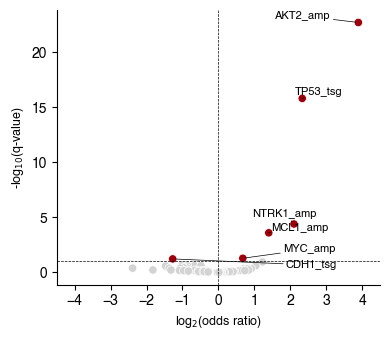

In [36]:
from adjustText import adjust_text
palette = {'positive':'#99000d', 'neutral':'lightgray', 'negative':'#228B22'}
res_df['color'] = ['positive' if fdr < 0.1 else 'neutral' for fdr in res_df.fdr]
res_df['odds_ratio'] = np.exp(res_df.beta)
res_df['log2_or'] = np.log2(res_df.odds_ratio)
res_df['log10_q_value'] = -np.log10(res_df.fdr)
plt.figure(figsize=(4, 3.5))
sns.scatterplot(
    data=res_df,
    x='log2_or',
    y='log10_q_value',
    hue='color',
    palette=palette,
    legend=False
)
text = []
for i in range(res_df.shape[0]):
    if res_df.fdr.iloc[i] < 0.1:
        t = plt.text(res_df.iloc[i]['log2_or'], res_df.iloc[i]['log10_q_value'], res_df.index[i], fontsize=8)
        text.append(t)
adjust_text(text, arrowprops=dict(arrowstyle='-', color='black', lw=0.5))
plt.axhline(-np.log10(0.1), color='black', linestyle='--', lw=0.5)
plt.axvline(0, color='black', linestyle='--', lw=0.5)
plt.xlabel('log$_{2}$(odds ratio)', fontsize = 9)
plt.ylabel(f'-log$_{{10}}$(q-value)', fontsize = 9)
plt.xticks(np.arange(-4, 5, 1))
plt.xlim(-4.5, 4.5)
# plt.yticks(np.arange(0, 14.1, 2))
mpl.rcParams['pdf.fonttype'] = 42
sns.despine()
plt.tight_layout()
mpl.rcParams['pdf.fonttype'] = 42
# plt.savefig('/home/boscoll/Projects/ccne1/results/figures/fig_3/volcano_overall.pdf', bbox_inches = 'tight')
plt.show()


In [37]:
res_df.loc['TP53_tsg']

p_value                0.0
beta               1.61838
fdr                    0.0
color             positive
odds_ratio         5.04491
log2_or           2.334829
log10_q_value    15.813553
Name: TP53_tsg, dtype: object

In [38]:
res_df.loc['CDH1_tsg']

p_value          0.004956
beta             -0.88206
fdr              0.061125
color            positive
odds_ratio       0.413929
log2_or         -1.272543
log10_q_value    1.213784
Name: CDH1_tsg, dtype: object

In [53]:
res_df.loc['ERBB2_amp']

p_value    0.131561
beta       0.492249
fdr        0.463196
Name: ERBB2_amp, dtype: float64

In [9]:
#frequency TP53 in ccne1 amp and non amp
ccne1_cohort[['ccne1_amp', 'receptor_status', 'sample_type']].join(alt_matrix[['TP53_tsg']]).groupby('ccne1_amp').TP53_tsg.value_counts(normalize=True).unstack().round(4).rename(index = {0:'No amp', 1:'CCNE1 Amp'}) * 100

TP53_tsg,0.0,1.0
ccne1_amp,,
No amp,57.96,42.04
CCNE1 Amp,16.33,83.67


In [10]:
#frequency TP53 in ccne1 amp and non amp
df_stats = ccne1_cohort[['ccne1_amp', 'receptor_status', 'sample_type', 'focal_amp']].join(alt_matrix[['TP53_tsg']]).query('ccne1_amp == 1')
(df_stats.groupby('focal_amp').TP53_tsg.value_counts(normalize=True).unstack().rename(index = {0:'No amp', 1:'CCNE1 Amp'}) * 100).round(2).astype(str) + '%'

TP53_tsg,0.0,1.0
focal_amp,,
focal,10.32%,89.68%
non-focal,22.4%,77.6%


In [167]:
%%R -i df_stats
df_stats$focal_amp = factor(df_stats$focal_amp, levels = c('non-focal', 'focal'))
fisher.test(table(df_stats$TP53_tsg, df_stats$focal_amp))


	Fisher's Exact Test for Count Data

data:  table(df_stats$TP53_tsg, df_stats$focal_amp)
p-value = 0.01061
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 1.176427 5.565727
sample estimates:
odds ratio 
  2.500068 



In [56]:
#logistic regression primary corrected for receptor subtype
ccne1_cohort_primary = ccne1_cohort.query('sample_type == "Primary"')
alt_matrix_primary = alt_matrix.query('index in @ccne1_cohort_primary.index')
res = []
for alt in [alt for alt in alt_matrix_primary.columns if alt != 'CCNE1_amp']:
    df_stat = ccne1_cohort_primary[['ccne1_amp', 'receptor_status']].join(alt_matrix_primary[[alt]])
    #receptor_status as dummies
    df_stat = pd.get_dummies(df_stat, columns=['receptor_status'], drop_first=True).astype(float)
    df_stat = df_stat.dropna()
    try: 
        model = sm.Logit(df_stat[alt], sm.add_constant(df_stat.drop(columns=[alt])))
        result = model.fit(disp=0)
        p_value = result.pvalues['ccne1_amp']
        beta = result.params['ccne1_amp']
        res.append({'gene': alt, 'p_value': p_value, 'beta': beta})
    except Exception as e:
        continue

res_df = pd.DataFrame(res)
res_df['fdr'] = fdr_correction(res_df.p_value)
res_df = res_df.sort_values('p_value')
res_df.set_index('gene', inplace=True)
res_df

,p_value,beta,fdr
gene,,,
AKT2_amp,4.326064e-11,2.631571,3.028245e-09
TP53_tsg,9.279393e-09,1.649460,3.247788e-07
NTRK1_amp,1.607048e-05,1.754735,3.749779e-04
MCL1_amp,7.368301e-05,1.202039,1.289453e-03
MYC_amp,3.012895e-03,0.695587,4.218052e-02
...,...,...,...
GAB2_amp,9.983418e-01,-18.316821,9.999734e-01
GPS2_tsg,9.991343e-01,-19.204202,9.999734e-01
SF3B1_mut,9.996322e-01,-21.864733,9.999734e-01


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


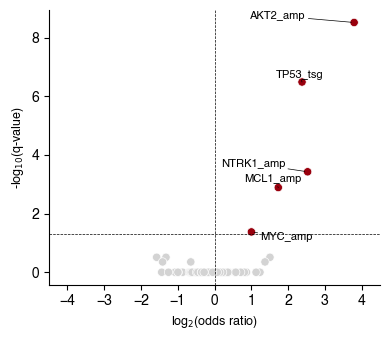

In [57]:
palette = {'positive':'#99000d', 'neutral':'lightgray', 'negative':'#228B22'}
res_df['color'] = ['positive' if fdr < 0.1 else 'neutral' for fdr in res_df.fdr]
res_df['odds_ratio'] = np.exp(res_df.beta)
res_df['log2_or'] = np.log2(res_df.odds_ratio)
res_df['log10_q_value'] = -np.log10(res_df.fdr)
plt.figure(figsize=(4, 3.5))
sns.scatterplot(
    data=res_df,
    x='log2_or',
    y='log10_q_value',
    hue='color',
    palette=palette,
    legend=False
)
text = []
for i in range(res_df.shape[0]):
    if res_df.fdr.iloc[i] < 0.1:
        t = plt.text(res_df.iloc[i]['log2_or'], res_df.iloc[i]['log10_q_value'], res_df.index[i], fontsize=8)
        text.append(t)
adjust_text(text, arrowprops=dict(arrowstyle='-', color='black', lw=0.5))
plt.axhline(-np.log10(0.05), color='black', linestyle='--', lw=0.5)
plt.axvline(0, color='black', linestyle='--', lw=0.5)
plt.xlabel('log$_{2}$(odds ratio)', fontsize = 9)
plt.ylabel(f'-log$_{{10}}$(q-value)', fontsize = 9)
plt.xticks(np.arange(-4, 5, 1))
plt.xlim(-4.5, 4.5)
# plt.yticks(np.arange(0, 14.1, 2))
mpl.rcParams['pdf.fonttype'] = 42
sns.despine()
plt.tight_layout()
mpl.rcParams['pdf.fonttype'] = 42
plt.savefig('/home/boscoll/Projects/ccne1/results/figures/fig_3/volcano_primary.pdf', bbox_inches = 'tight')
plt.show()


In [61]:
#logistic regression metastasis corrected for receptor subtype
ccne1_cohort_mets = ccne1_cohort.query('sample_type != "Primary"')
alt_matrix_mets = alt_matrix.query('index in @ccne1_cohort_mets.index')
res = []
for alt in [alt for alt in alt_matrix_mets.columns if alt != 'CCNE1_amp']:
    df_stat = ccne1_cohort_mets[['ccne1_amp', 'receptor_status']].join(alt_matrix_mets[[alt]])
    #receptor_status as dummies
    df_stat = pd.get_dummies(df_stat, columns=['receptor_status'], drop_first=True).astype(float)
    df_stat = df_stat.dropna()
    try: 
        model = sm.Logit(df_stat[alt], sm.add_constant(df_stat.drop(columns=[alt])))
        result = model.fit(disp=0)
        p_value = result.pvalues['ccne1_amp']
        beta = result.params['ccne1_amp']
        res.append({'gene': alt, 'p_value': p_value, 'beta': beta})
    except Exception as e:
        continue
res_df = pd.DataFrame(res)
res_df['fdr'] = fdr_correction(res_df.p_value)
res_df = res_df.sort_values('p_value')
res_df.set_index('gene', inplace=True)
res_df

,p_value,beta,fdr
gene,,,
AKT2_amp,1.855193e-16,2.846135,1.372843e-14
TP53_tsg,1.879810e-10,1.575840,6.955297e-09
TERT_amp,3.137029e-03,1.259901,7.738006e-02
CREBBP_tsg,2.778508e-02,1.099664,4.537798e-01
NTRK1_amp,3.592786e-02,1.032518,4.537798e-01
...,...,...,...
PIK3R1_tsg,9.998888e-01,-26.010895,1.000000e+00
SF3B1_mut,9.999353e-01,-25.983316,1.000000e+00
YES1_amp,1.000000e+00,-48.570481,1.000000e+00


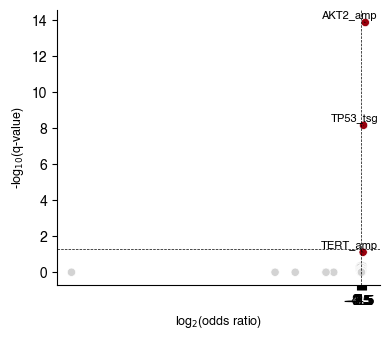

In [81]:
#volcano plot of correlation results
palette = {'positive':'#99000d', 'neutral':'lightgray', 'negative':'#228B22'}
res_df['color'] = ['positive' if fdr < 0.1 else 'neutral' for fdr in res_df.fdr]
res_df['odds_ratio'] = np.exp(res_df.beta)
res_df['log2_or'] = np.log2(res_df.odds_ratio)
res_df['log10_q_value'] = -np.log10(res_df.fdr)
plt.figure(figsize=(4, 3.5))
sns.scatterplot(
    data=res_df,
    x='log2_or',
    y='log10_q_value',
    hue='color',
    palette=palette,
    legend=False
)
text = []
for i in range(res_df.shape[0]):
    if res_df.fdr.iloc[i] < 0.1:
        t = plt.text(res_df.iloc[i]['log2_or'], res_df.iloc[i]['log10_q_value'], res_df.index[i], fontsize=8)
        text.append(t)
adjust_text(text, arrowprops=dict(arrowstyle='-', color='black', lw=0.5))
plt.axhline(-np.log10(0.05), color='black', linestyle='--', lw=0.5)
plt.axvline(0, color='black', linestyle='--', lw=0.5)
plt.xlabel('log$_{2}$(odds ratio)', fontsize = 9)
plt.ylabel(f'-log$_{{10}}$(q-value)', fontsize = 9)
plt.xticks(np.arange(-4, 5, 1))
plt.xlim(-4.5, 4.5)
mpl.rcParams['pdf.fonttype'] = 42
sns.despine()
plt.tight_layout()
mpl.rcParams['pdf.fonttype'] = 42
# plt.savefig('/home/boscoll/Projects/ccne1/results/figures/fig_3/volcano_metastasis.pdf', bbox_inches = 'tight')
plt.show()


***HR+/HER2-***

In [82]:
ccne1_cohort_hr = ccne1_cohort.query('receptor_status == "HR"')
alt_matrix_hr = alt_matrix.loc[alt_matrix.index.isin(ccne1_cohort_hr.index)]

In [84]:
#fisher test for gene associations
ccne1_cohort_hr['ccne1_amp'] = pd.Categorical(ccne1_cohort_hr.ccne1_amp, categories=[0, 1])
ccne1_cohort_hr = ccne1_cohort_hr.sort_values('ccne1_amp')
res = []
for alt in [alt for alt in alt_matrix_hr.columns if alt != 'CCNE1_amp']:
    df_stat = ccne1_cohort_hr[['ccne1_amp']].join(alt_matrix_hr[[alt]])
    cont_table = pd.crosstab(df_stat.ccne1_amp, df_stat[alt])
    if cont_table.shape == (2, 2):
        oddsratio, pvalue = fisher_exact(cont_table)
        res.append({'gene': alt, 'oddsratio': oddsratio, 'pvalue': pvalue})
res_df = pd.DataFrame(res)
res_df['fdr'] = fdr_correction(res_df.pvalue)
res_df = res_df.sort_values('pvalue')
res_hr_genes = res_df
res_df.set_index('gene', inplace=True)
res_hr_genes

,oddsratio,pvalue,fdr
gene,,,
TP53_tsg,4.972759,3.073550e-13,2.274427e-11
AKT2_amp,15.184488,6.043941e-05,2.236258e-03
MYC_amp,2.391963,2.229237e-03,5.498785e-02
MCL1_amp,3.191870,6.239764e-03,8.261663e-02
NKX3-1_tsg,3.985299,6.256991e-03,8.261663e-02
...,...,...,...
MDM2_amp,0.857590,1.000000e+00,1.000000e+00
STK11_tsg,0.000000,1.000000e+00,1.000000e+00
SMAD4_tsg,0.536038,1.000000e+00,1.000000e+00


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


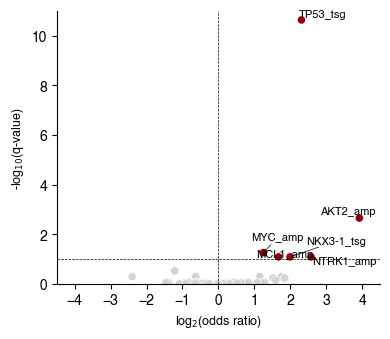

In [120]:
#volcano plot of correlation results
palette = {'positive':'#99000d', 'neutral':'lightgray', 'negative':'#228B22'}
res_hr_genes['color'] = ['positive' if fdr < 0.1 else 'neutral' for fdr in res_hr_genes.fdr]
res_hr_genes['log2_or'] = np.log2(res_hr_genes.oddsratio)
res_hr_genes['log10_q_value'] = -np.log10(res_hr_genes.fdr)
plt.figure(figsize=(4, 3.5))
sns.scatterplot(
    data=res_hr_genes,
    x='log2_or',
    y='log10_q_value',
    hue='color',
    palette=palette,
    legend=False
)
text = []
for i in range(res_hr_genes.shape[0]):
    if res_hr_genes.fdr.iloc[i] < 0.1:
        t = plt.text(res_hr_genes.iloc[i]['log2_or'], res_hr_genes.iloc[i]['log10_q_value'], res_hr_genes.index[i], fontsize=8)
        text.append(t)
adjust_text(text, arrowprops=dict(arrowstyle='-', color='black', lw=0.5))
plt.axhline(-np.log10(0.1), color='black', linestyle='--', lw=0.5)
plt.axvline(0, color='black', linestyle='--', lw=0.5)
plt.xlabel('log$_{2}$(odds ratio)', fontsize = 9)
plt.ylabel(f'-log$_{{10}}$(q-value)', fontsize = 9)
plt.xticks(np.arange(-4, 5, 1))
plt.xlim(-4.5, 4.5)
plt.ylim(0, 11)
mpl.rcParams['pdf.fonttype'] = 42
sns.despine()
plt.tight_layout()
mpl.rcParams['pdf.fonttype'] = 42
plt.savefig('/home/boscoll/Projects/ccne1/results/figures/fig_3/volcano_erpos.pdf', bbox_inches = 'tight')
plt.show()


***HER2+***

In [87]:
ccne1_cohort_her2 = ccne1_cohort.query('receptor_status == "HER2"')
alt_matrix_her2 = alt_matrix.loc[alt_matrix.index.isin(ccne1_cohort_her2.index)]

In [90]:
#fisher test for gene associations
ccne1_cohort_her2['ccne1_amp'] = pd.Categorical(ccne1_cohort_her2.ccne1_amp, categories=[0, 1])
ccne1_cohort_her2 = ccne1_cohort_her2.sort_values('ccne1_amp')
res = []
for alt in [alt for alt in alt_matrix_her2.columns if alt != 'CCNE1_amp']:
    df_stat = ccne1_cohort_her2[['ccne1_amp']].join(alt_matrix_her2[[alt]])
    cont_table = pd.crosstab(df_stat.ccne1_amp, df_stat[alt])
    if cont_table.shape == (2, 2):
        oddsratio, pvalue = fisher_exact(cont_table)
        res.append({'gene': alt, 'oddsratio': oddsratio, 'pvalue': pvalue})
res_df = pd.DataFrame(res)
res_df['fdr'] = fdr_correction(res_df.pvalue)
res_df = res_df.sort_values('pvalue')
res_her2_genes = res_df
res_df.set_index('gene', inplace=True)
res_her2_genes

,oddsratio,pvalue,fdr
gene,,,
AKT2_amp,18.262391,0.000001,0.000085
TP53_tsg,3.110220,0.000909,0.033631
11q13_amp,0.174866,0.004520,0.111494
NOTCH1_tsg,8.722222,0.012713,0.235198
KRAS_amp,7.145455,0.056028,0.781434
...,...,...,...
MDM4_amp,0.890323,1.000000,1.000000
SMAD4_tsg,0.687500,1.000000,1.000000
TERT_amp,0.623377,1.000000,1.000000


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


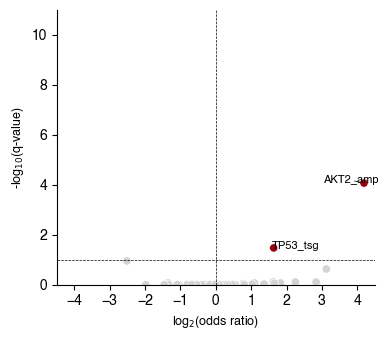

In [118]:
#volcano plot of correlation results
palette = {'positive':'#99000d', 'neutral':'lightgray', 'negative':'#228B22'}
res_her2_genes['color'] = ['positive' if fdr < 0.1 else 'neutral' for fdr in res_her2_genes.fdr]
res_her2_genes['log2_or'] = np.log2(res_her2_genes.oddsratio)
res_her2_genes['log10_q_value'] = -np.log10(res_her2_genes.fdr)
plt.figure(figsize=(4, 3.5))
sns.scatterplot(
    data=res_her2_genes,
    x='log2_or',
    y='log10_q_value',
    hue='color',
    palette=palette,
    legend=False
)
text = []
for i in range(res_her2_genes.shape[0]):
    if res_her2_genes.fdr.iloc[i] < 0.1:
        t = plt.text(res_her2_genes.iloc[i]['log2_or'], res_her2_genes.iloc[i]['log10_q_value'], res_her2_genes.index[i], fontsize=8)
        text.append(t)
adjust_text(text, arrowprops=dict(arrowstyle='-', color='black', lw=0.5))
plt.axhline(-np.log10(0.1), color='black', linestyle='--', lw=0.5)
plt.axvline(0, color='black', linestyle='--', lw=0.5)
plt.xlabel('log$_{2}$(odds ratio)', fontsize = 9)
plt.ylabel(f'-log$_{{10}}$(q-value)', fontsize = 9)
plt.ylim(0, 11)
plt.xticks(np.arange(-4, 5, 1))
plt.xlim(-4.5, 4.5)
mpl.rcParams['pdf.fonttype'] = 42
sns.despine()
plt.tight_layout()
mpl.rcParams['pdf.fonttype'] = 42
plt.savefig('/home/boscoll/Projects/ccne1/results/figures/fig_3/volcano_her2.pdf', bbox_inches = 'tight')
plt.show()


***TNBC+***

In [92]:
ccne1_cohort_tnbc = ccne1_cohort.query('receptor_status == "TNBC"')
alt_matrix_tnbc = alt_matrix.loc[alt_matrix.index.isin(ccne1_cohort_tnbc.index)]

In [111]:
#fisher test for gene associations
ccne1_cohort_tnbc['ccne1_amp'] = pd.Categorical(ccne1_cohort_tnbc.ccne1_amp, categories=[0, 1])
ccne1_cohort_tnbc = ccne1_cohort_tnbc.sort_values('ccne1_amp')
res = []
for alt in [alt for alt in alt_matrix_tnbc.columns if alt != 'CCNE1_amp']:
    df_stat = ccne1_cohort_tnbc[['ccne1_amp']].join(alt_matrix_tnbc[[alt]])
    cont_table = pd.crosstab(df_stat.ccne1_amp, df_stat[alt])
    if cont_table.shape == (2, 2):
        oddsratio, pvalue = fisher_exact(cont_table)
        res.append({'gene': alt, 'oddsratio': oddsratio, 'pvalue': pvalue})
res_df = pd.DataFrame(res)
res_df['fdr'] = fdr_correction(res_df.pvalue)
res_df = res_df.sort_values('pvalue')
res_tnbc_genes = res_df
res_tnbc_genes.set_index('gene', inplace=True)
res_tnbc_genes

,oddsratio,pvalue,fdr
gene,,,
AKT2_amp,13.066845,3.026968e-11,2.239956e-09
TP53_tsg,22.831126,1.208390e-07,4.471042e-06
9p21_deletion,0.000000,1.260645e-04,3.109591e-03
CDH1_tsg,0.000000,3.041892e-03,4.964087e-02
NTRK1_amp,3.562224,3.354113e-03,4.964087e-02
...,...,...,...
GPS2_tsg,0.000000,1.000000e+00,1.000000e+00
MDM4_amp,0.690794,1.000000e+00,1.000000e+00
SRC_amp,0.000000,1.000000e+00,1.000000e+00


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


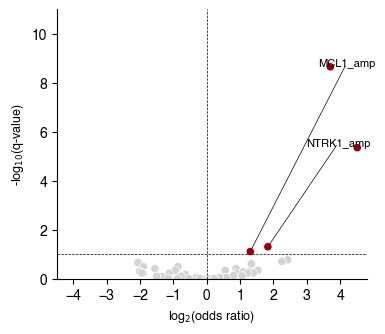

In [119]:
#volcano plot of correlation results
palette = {'positive':'#99000d', 'neutral':'lightgray', 'negative':'#228B22'}
res_tnbc_genes['color'] = ['positive' if fdr < 0.1 else 'neutral' for fdr in res_tnbc_genes.fdr]
res_tnbc_genes['log2_or'] = np.log2(res_tnbc_genes.oddsratio)
res_tnbc_genes['log10_q_value'] = -np.log10(res_tnbc_genes.fdr)
plt.figure(figsize=(4, 3.5))
sns.scatterplot(
    data=res_tnbc_genes,
    x='log2_or',
    y='log10_q_value',
    hue='color',
    palette=palette,
    legend=False
)
text = []
for i in range(res_tnbc_genes.shape[0]):
    if res_tnbc_genes.fdr.iloc[i] < 0.1:
        t = plt.text(res_tnbc_genes.iloc[i]['log2_or'], res_tnbc_genes.iloc[i]['log10_q_value'], res_tnbc_genes.index[i], fontsize=8)
        text.append(t)
adjust_text(text, arrowprops=dict(arrowstyle='-', color='black', lw=0.5),expand_text=(0.5, 0.5),expand_points=(0.5, 0.5), force_text=(0.2, 0.2))
plt.axhline(-np.log10(0.1), color='black', linestyle='--', lw=0.5)
plt.axvline(0, color='black', linestyle='--', lw=0.5)
plt.xlabel('log$_{2}$(odds ratio)', fontsize = 9)
plt.ylabel(f'-log$_{{10}}$(q-value)', fontsize = 9)
plt.ylim(0, 11)
plt.xlim(-4.5, 4.8)
plt.xticks(np.arange(-4, 5, 1))
mpl.rcParams['pdf.fonttype'] = 42
sns.despine()
plt.savefig('/home/boscoll/Projects/ccne1/results/figures/fig_3/volcano_tnbc.pdf', bbox_inches = 'tight')
plt.show()


## FACETS biomarkers

## FGA

***Overall cohort***

In [19]:
ccne1_cohort = pd.read_csv('/home/boscoll/Projects/ccne1/data/4_may/ccne1_cohort.csv', index_col=0)
facets_sample_level = pd.read_csv('/home/boscoll/Projects/ccne1/data/4_may/facets_biomarkers.csv', index_col=0)
facets_sample_level = facets_sample_level.join(ccne1_cohort[['receptor_status', 'ccne1_amp', 'focal_amp', 'sample_type']])

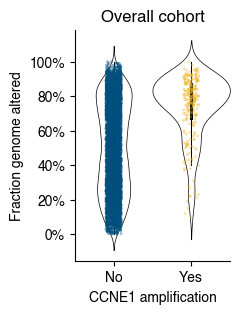

median FGA in CCNE1 amplified tumors: 79.00%
median FGA in non-CCNE1 amplified tumors: 50.00%


In [22]:
plt.figure(figsize=(2, 3))
sns.violinplot(data=facets_sample_level, x='ccne1_amp', y='fga', color='white', edgecolor='black', linewidth=0.5, width=1)
sns.stripplot(data=facets_sample_level, x='ccne1_amp', y='fga', color='black', size=2, jitter=True,  alpha=0.4, hue='ccne1_amp', palette=palette_ccne1, legend=False)
plt.xticks([0, 1], ['No', 'Yes'])
plt.xlabel('CCNE1 amplification')
plt.ylabel('Fraction genome altered')
plt.title('Overall cohort', fontweight='bold')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
sns.despine()
# plt.savefig('/home/boscoll/Projects/ccne1/results/figures/fig_3/fga_by_ccne1_amp.pdf', bbox_inches='tight')
plt.show()
print(f'median FGA in CCNE1 amplified tumors: {facets_sample_level.query("ccne1_amp == 1").fga.median():.2%}')
print(f'median FGA in non-CCNE1 amplified tumors: {facets_sample_level.query("ccne1_amp == 0").fga.median():.2%}')

In [187]:
#fold change fga in ccne1 amplified vs non amplified
fga_amp = facets_sample_level.query('ccne1_amp == 1').fga
fga_non_amp = facets_sample_level.query('ccne1_amp == 0').fga
fold_change = fga_amp.median() / fga_non_amp.median()
print(f'Fold change in FGA between CCNE1 amplified and non-amplified samples: {fold_change:.2f}')

Fold change in FGA between CCNE1 amplified and non-amplified samples: 1.58


In [188]:
%%R -i facets_sample_level
wilcox.test(fga ~ ccne1_amp, data = facets_sample_level)


	Wilcoxon rank sum test with continuity correction

data:  fga by ccne1_amp
W = 365896, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



In [190]:
import statsmodels.api as sm
#association with higher FGA once corrected for receptor status and sample type (linear regression)
df_stats = facets_sample_level[['ccne1_amp', 'receptor_status', 'sample_type', 'fga']]
df_stats = pd.get_dummies(df_stats, columns=['receptor_status', 'sample_type'], drop_first=True).astype(float)
df_stats.dropna(inplace=True)
model = sm.OLS(df_stats['fga'], sm.add_constant(df_stats.drop('fga', axis=1)))
results = model.fit()
pd.DataFrame({'feature': results.params.index, 'beta': results.params.values, 'p_value': results.pvalues.values})

,feature,beta,p_value
0,const,0.596278,8.730186e-211
1,ccne1_amp,0.182501,1.214953e-29
2,receptor_status_HR,-0.124233,4.800219e-40
3,receptor_status_TNBC,0.064339,6.322557e-09
4,sample_type_Metastasis,0.014278,3.976875e-01
5,sample_type_Primary,-0.069452,4.888935e-05
6,sample_type_QA: Metadata ETL Update needed. Sy...,-0.138617,2.145599e-01


In [191]:
#association with higher FGA once corrected for receptor status and sample type (linear regression) --> CORRECTION ALSO FOR TP53
df_stats = facets_sample_level[['ccne1_amp', 'receptor_status', 'sample_type', 'fga']].join(alt_matrix[['TP53_tsg']])
df_stats = pd.get_dummies(df_stats, columns=['receptor_status', 'sample_type'], drop_first=True).astype(float)
df_stats.dropna(inplace=True)
model = sm.OLS(df_stats['fga'], sm.add_constant(df_stats.drop('fga', axis=1)))
results = model.fit()
pd.DataFrame({'feature': results.params.index, 'beta': results.params.values, 'p_value': results.pvalues.values})

,feature,beta,p_value
0,const,0.485296,2.084363e-147
1,ccne1_amp,0.133783,2.335161e-18
2,TP53_tsg,0.183554,4.644489e-152
3,receptor_status_HR,-0.053925,3.826550e-09
4,receptor_status_TNBC,0.030401,3.940113e-03
5,sample_type_Metastasis,0.008640,5.949070e-01
6,sample_type_Primary,-0.072475,1.071200e-05
7,sample_type_QA: Metadata ETL Update needed. Sy...,-0.140540,1.826416e-01


In [194]:
%%R -i facets_sample_level
#linear regression fga ~ ccne1_amp + wgd
summary(lm(fga ~ ccne1_amp + wgd, data = facets_sample_level))


Call:
lm(formula = fga ~ ccne1_amp + wgd, data = facets_sample_level)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.73305 -0.15687 -0.00687  0.13595  0.57313 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.416872   0.003189 130.737  < 2e-16 ***
ccne1_amp   0.109786   0.014062   7.807 6.79e-15 ***
wgdTRUE     0.337176   0.006172  54.634  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.2154 on 6315 degrees of freedom
  (1 observation deleted due to missingness)
Multiple R-squared:  0.3413,	Adjusted R-squared:  0.3411 
F-statistic:  1636 on 2 and 6315 DF,  p-value: < 2.2e-16



***HR+/HER2- cohort***

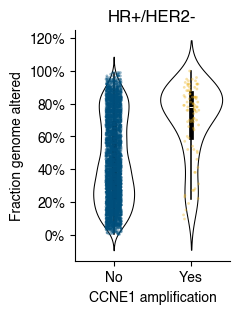

In [52]:
facets_sample_level_hr = facets_sample_level.query('receptor_status == "HR"')
plt.figure(figsize=(2, 3))
sns.violinplot(data=facets_sample_level_hr, x='ccne1_amp', y='fga', edgecolor='black', linewidth=0.75, color='white')
sns.stripplot(data=facets_sample_level_hr, x='ccne1_amp', y='fga', color='black', size=2, jitter=True,  alpha=0.4, hue='ccne1_amp', palette=palette_ccne1, legend=False)
plt.xticks([0, 1], ['No', 'Yes'])
plt.xlabel('CCNE1 amplification')
plt.ylabel('Fraction genome altered')
plt.title('HR+/HER2-', fontweight='bold')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
sns.despine()
# plt.savefig('/home/boscoll/Projects/ccne1/results/figures/fig_3/fga_by_ccne1_amp_hr.pdf', bbox_inches='tight')
plt.show()

In [205]:
%%R -i facets_sample_level_hr
wilcox.test(fga ~ ccne1_amp, data = facets_sample_level_hr)


	Wilcoxon rank sum test with continuity correction

data:  fga by ccne1_amp
W = 86695, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



***HER2+ cohort***

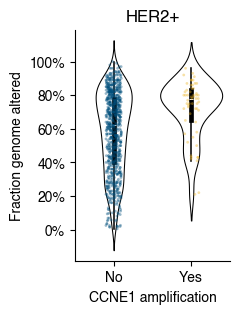

In [53]:
facets_sample_level_her2 = facets_sample_level.query('receptor_status == "HER2"')
plt.figure(figsize=(2, 3))
sns.violinplot(data=facets_sample_level_her2, x='ccne1_amp', y='fga', edgecolor='black', linewidth=0.75, color='white')
sns.stripplot(data=facets_sample_level_her2, x='ccne1_amp', y='fga', color='black', size=2, jitter=True,  alpha=0.4, hue='ccne1_amp', palette=palette_ccne1, legend=False)
plt.xticks([0, 1], ['No', 'Yes'])
plt.xlabel('CCNE1 amplification')
plt.ylabel('Fraction genome altered')
plt.title('HER2+', fontweight='bold')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
sns.despine()
# plt.savefig('/home/boscoll/Projects/ccne1/results/figures/fig_3/fga_by_ccne1_amp_her2.pdf', bbox_inches='tight')
plt.show()

In [209]:
%%R -i facets_sample_level_her2
wilcox.test(fga ~ ccne1_amp, data = facets_sample_level_hr)


	Wilcoxon rank sum test with continuity correction

data:  fga by ccne1_amp
W = 86695, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



***TNBC cohort***

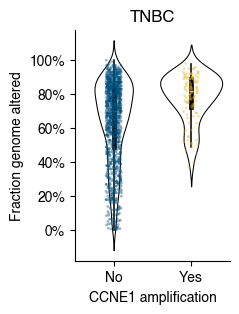

In [54]:
facets_sample_level_tnbc = facets_sample_level.query('receptor_status == "TNBC"')
plt.figure(figsize=(2, 3))
sns.violinplot(data=facets_sample_level_tnbc, x='ccne1_amp', y='fga', edgecolor='black', linewidth=0.75, color='white')
sns.stripplot(data=facets_sample_level_tnbc, x='ccne1_amp', y='fga', color='black', size=2, jitter=True,  alpha=0.4, hue='ccne1_amp', palette=palette_ccne1, legend=False)
plt.xticks([0, 1], ['No', 'Yes'])
plt.xlabel('CCNE1 amplification')
plt.ylabel('Fraction genome altered')
plt.title('TNBC', fontweight='bold')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
sns.despine()
# plt.savefig('/home/boscoll/Projects/ccne1/results/figures/fig_3/fga_by_ccne1_amp_tnbc.pdf', bbox_inches='tight')
plt.show()

In [212]:
%%R -i facets_sample_level_tnbc
wilcox.test(fga ~ ccne1_amp, data = facets_sample_level_tnbc)


	Wilcoxon rank sum test with continuity correction

data:  fga by ccne1_amp
W = 38058, p-value = 1.41e-09
alternative hypothesis: true location shift is not equal to 0



## Fraction LOH

In [23]:
(facets_sample_level.groupby('ccne1_amp').frac_loh.describe() * 100).round(2).astype(str) + '%'

,count,mean,std,min,25%,50%,75%,max
ccne1_amp,,,,,,,,
0.0,606700.0%,29.0%,20.83%,0.0%,12.0%,24.0%,43.0%,99.0%
1.0,25100.0%,39.66%,19.82%,1.0%,24.0%,37.0%,52.0%,92.0%


In [197]:
#fold change fraction loh
loh_amp = facets_sample_level.query('ccne1_amp == 1').frac_loh
loh_non_amp = facets_sample_level.query('ccne1_amp == 0').frac_loh
fold_change_loh = loh_amp.median() / loh_non_amp.median()
print(f'Fold change in fraction LOH between CCNE1 amplified and non-amplified samples: {fold_change_loh:.2f}')

Fold change in fraction LOH between CCNE1 amplified and non-amplified samples: 1.54


In [112]:
%%R -i facets_sample_level
wilcox.test(facets_sample_level$frac_loh ~ facets_sample_level$ccne1_amp)


	Wilcoxon rank sum test with continuity correction

data:  facets_sample_level$frac_loh by facets_sample_level$ccne1_amp
W = 521504, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



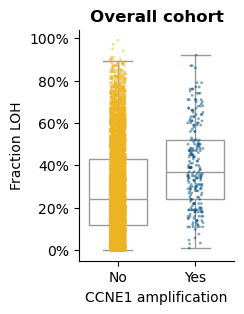

In [107]:
plt.figure(figsize=(2, 3))
sns.boxplot(data=facets_sample_level, x='ccne1_amp', y='frac_loh', showfliers=False, width=0.75, color='white')
sns.stripplot(data=facets_sample_level, x='ccne1_amp', y='frac_loh', color='black', size=2, jitter=True,  alpha=0.5, hue='ccne1_amp', palette=palette, legend=False)
plt.xticks([0, 1], ['No', 'Yes'])
plt.xlabel('CCNE1 amplification')
plt.ylabel('Fraction LOH')
plt.title('Overall cohort', fontweight='bold')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
sns.despine()

## WGD

***Overall***

In [70]:
print(f'overall frequency of WGD: {(facets_sample_level.wgd.astype(int).sum() / facets_sample_level.shape[0]).round(3)}')

overall frequency of WGD: 0.272


In [ ]:
#frequency of WGD in CCNE1 amplified vs non-amplified samples
facets_sample_level.groupby('ccne1_amp').wgd.value_counts(normalize=True).unstack()

wgd,False,True
ccne1_amp,,
0.0,0.742706,0.257294
1.0,0.370518,0.629482


In [ ]:
#among focal and non focal CCCNE1 amplifications
facets_sample_level.query('ccne1_amp == 1').groupby('focal_amp').wgd.value_counts(normalize=True).unstack()

wgd,False,True
focal_amp,,
focal,0.380952,0.619048
non-focal,0.360000,0.640000


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


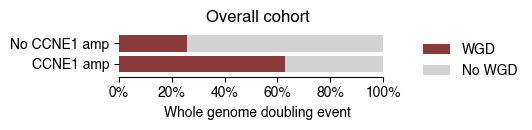

In [ ]:
color_wgd = {True:'#8B3A3A', False:'lightgray'}
wgd_table =  facets_sample_level.groupby('ccne1_amp').wgd.value_counts(normalize=True).unstack()
wgd_table = wgd_table.loc[[1, 0]]
wgd_table = wgd_table.iloc[:, ::-1]
wgd_table.columns = ['WGD', 'No WGD']
wgd_table.plot(kind='barh', stacked=True, color=[color_wgd[True], color_wgd[False]], figsize=(5.5, 1.4), edgecolor='none', width=0.8)
plt.xlabel('Whole genome doubling event')
plt.ylabel('')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))
sns.despine(trim = True, left = True)
plt.tick_params(left=True, bottom = True)
plt.yticks([0, 1], ['CCNE1 amp', 'No CCNE1 amp'])
plt.legend(frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Overall cohort', fontweight='bold')
plt.tight_layout()
# plt.savefig('/home/boscoll/Projects/ccne1/results/figures/fig_3/wgd_by_ccne1_amp.pdf', bbox_inches='tight')
plt.show()

In [46]:
(facets_sample_level.groupby('ccne1_amp').wgd.value_counts(normalize=True).unstack() * 100).round(2).astype(str) + '%'

wgd,False,True
ccne1_amp,,
0.0,74.27%,25.73%
1.0,37.05%,62.95%


In [47]:
%%R -i facets_sample_level
fisher.test(table(facets_sample_level$ccne1_amp, facets_sample_level$wgd))


	Fisher's Exact Test for Count Data

data:  table(facets_sample_level$ccne1_amp, facets_sample_level$wgd)
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 3.745218 6.446873
sample estimates:
odds ratio 
  4.902181 



In [50]:
#corrected for TP53 alteration
df_stats = facets_sample_level[['ccne1_amp', 'wgd']].join(alt_matrix[['TP53_tsg']]).dropna().astype(float)
model = sm.Logit(df_stats['wgd'], sm.add_constant(df_stats.drop('wgd', axis=1)))
results = model.fit(disp=0)
pd.DataFrame({'feature': results.params.index, 'beta': results.params.values, 'p_value': results.pvalues.values})

,feature,beta,p_value
0,const,-1.440855,2.285343e-246
1,ccne1_amp,1.272028,1.524739e-20
2,TP53_tsg,0.845442,4.101357e-46


***HRpos***

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


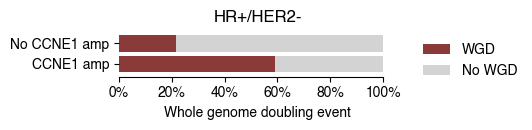

In [61]:
wgd_table =  facets_sample_level_hr.groupby('ccne1_amp').wgd.value_counts(normalize=True).unstack()
wgd_table = wgd_table.loc[[1, 0]]
wgd_table = wgd_table.iloc[:, ::-1]
wgd_table.columns = ['WGD', 'No WGD']
wgd_table.plot(kind='barh', stacked=True, color=['#8B3A3A', 'lightgray'], figsize=(5.5, 1.4), edgecolor='none', width=0.8)
plt.xlabel('Whole genome doubling event')
plt.ylabel('')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))
sns.despine(trim = True, left = True)
plt.tick_params(left=True, bottom = True)
plt.yticks([0, 1], ['CCNE1 amp', 'No CCNE1 amp'])
plt.legend(frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('HR+/HER2-', fontweight='bold')
plt.tight_layout()
plt.savefig('/home/boscoll/Projects/ccne1/results/figures/fig_3/wgd_by_ccne1_amp_hr.pdf', bbox_inches='tight')
plt.show()

In [217]:
%%R -i facets_sample_level_hr
fisher.test(table(facets_sample_level_hr$ccne1_amp, facets_sample_level_hr$wgd))


	Fisher's Exact Test for Count Data

data:  table(facets_sample_level_hr$ccne1_amp, facets_sample_level_hr$wgd)
p-value = 5.053e-14
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 3.361131 8.365046
sample estimates:
odds ratio 
  5.277396 



***HER2pos***

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


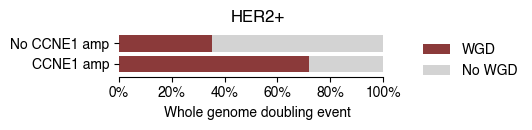

In [62]:
wgd_table =  facets_sample_level_her2.groupby('ccne1_amp').wgd.value_counts(normalize=True).unstack()
wgd_table = wgd_table.loc[[1, 0]]
wgd_table = wgd_table.iloc[:, ::-1]
wgd_table.columns = ['WGD', 'No WGD']
wgd_table.plot(kind='barh', stacked=True, color=['#8B3A3A', 'lightgray'], figsize=(5.5, 1.4), edgecolor='none', width=0.8)
plt.xlabel('Whole genome doubling event')
plt.ylabel('')
#y as percentage
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))
sns.despine(trim = True, left = True)
plt.tick_params(left=True, bottom = True)
plt.yticks([0, 1], ['CCNE1 amp', 'No CCNE1 amp'])
plt.legend(frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('HER2+', fontweight='bold')
plt.tight_layout()
plt.savefig('/home/boscoll/Projects/ccne1/results/figures/fig_3/wgd_by_ccne1_amp_her2.pdf', bbox_inches='tight')
plt.show()

In [58]:
%%R -i facets_sample_level_her2
fisher.test(table(facets_sample_level_her2$ccne1_amp, facets_sample_level_her2$wgd))


	Fisher's Exact Test for Count Data

data:  table(facets_sample_level_her2$ccne1_amp, facets_sample_level_her2$wgd)
p-value = 1.12e-07
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 2.523318 9.133884
sample estimates:
odds ratio 
   4.69339 



***TNBC***

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


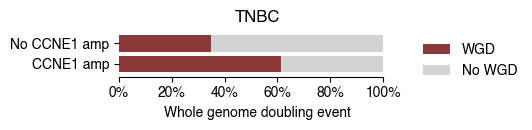

In [63]:
wgd_table =  facets_sample_level_tnbc.groupby('ccne1_amp').wgd.value_counts(normalize=True).unstack()
wgd_table = wgd_table.loc[[1, 0]]
wgd_table = wgd_table.iloc[:, ::-1]
wgd_table.columns = ['WGD', 'No WGD']
wgd_table.plot(kind='barh', stacked=True, color=['#8B3A3A', 'lightgray'], figsize=(5.5, 1.4), edgecolor='none', width=0.8)
plt.xlabel('Whole genome doubling event')
plt.ylabel('')
#y as percentage
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))
sns.despine(trim = True, left = True)
plt.tick_params(left=True, bottom = True)
plt.yticks([0, 1], ['CCNE1 amp', 'No CCNE1 amp'])
plt.legend(frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('TNBC', fontweight='bold')
plt.tight_layout()
plt.savefig('/home/boscoll/Projects/ccne1/results/figures/fig_3/wgd_by_ccne1_amp_tnbc.pdf', bbox_inches='tight')
plt.show()

In [222]:
%%R -i facets_sample_level_tnbc
fisher.test(table(facets_sample_level_tnbc$ccne1_amp, facets_sample_level_tnbc$wgd))


	Fisher's Exact Test for Count Data

data:  table(facets_sample_level_tnbc$ccne1_amp, facets_sample_level_tnbc$wgd)
p-value = 1.529e-07
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 1.933672 4.585783
sample estimates:
odds ratio 
  2.963608 



## TMB

In [164]:
sample_oncokb = pd.read_table('/scratch/razavip/boscoll/cdk_predict/data/development_cohort/clinical/data_clinical_sample_somatic.oncokb.txt', index_col=0)
tmb = sample_oncokb.query('index in @ccne1_cohort.index')['CVR_TMB_SCORE'].to_frame('TMB')

In [165]:
df_stats = tmb.join(ccne1_cohort[['ccne1_amp']])
print(df_stats.groupby('ccne1_amp').TMB.describe())


            count      mean       std  min  25%  50%  75%    max
ccne1_amp                                                       
0          6009.0  4.800316  5.650862 -1.0  2.5  3.5  5.6  157.1
1           250.0  4.484400  3.870768  0.8  2.5  3.5  5.3   36.0


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


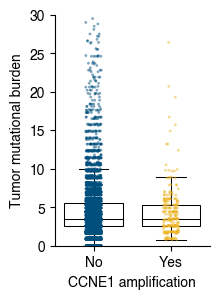

In [176]:
plt.figure(figsize=(2, 3))
sns.boxplot(
    data=df_stats,
    x='ccne1_amp',
    y='TMB',
    showfliers=False,
    width=0.75,
    color='white',
    linecolor='black',
    linewidth=0.75
)
sns.stripplot(
    data=df_stats,
    x='ccne1_amp',
    y='TMB',
    color='black',
    size=2,
    jitter=True,
    alpha=0.5,
    hue='ccne1_amp',
    palette=palette_ccne1,
    legend=False
)
plt.ylim(0, 30)
plt.xticks([0, 1], ['No', 'Yes'])
plt.xlabel('CCNE1 amplification')
plt.ylabel('Tumor mutational burden')
sns.despine()
plt.savefig('/home/boscoll/Projects/ccne1/results/figures/fig_3/tmb_by_ccne1_amp.pdf', bbox_inches='tight')
plt.show()

In [166]:
%%R -i df_stats
wilcox.test(df_stats$TMB ~ df_stats$ccne1_amp)


	Wilcoxon rank sum test with continuity correction

data:  df_stats$TMB by df_stats$ccne1_amp


W = 749562, p-value = 0.9554
alternative hypothesis: true location shift is not equal to 0



# SigMA

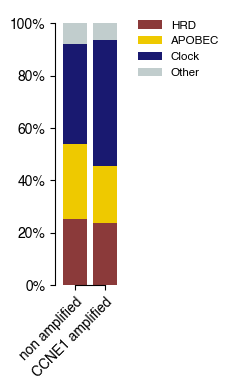

In [75]:
palette_temp = {'APOBEC':'#EEC900', 'HRD':'#8B3A3A', 'Clock':'#191970', 'Other':'#C1CDCD'}
y_sig_melted_bar  = sigma[['categ']].join(ccne1_cohort[['ccne1_amp', 'receptor_status']]).groupby('ccne1_amp').categ.value_counts(normalize=True).unstack()
y_sig_melted_bar = y_sig_melted_bar[['HRD', 'APOBEC', 'Clock', 'Other']]
y_sig_melted_bar.plot(kind='bar', stacked=True, color=palette_temp, figsize=(2.5,4), edgecolor='none', width=0.8)
plt.xlabel('')
plt.ylabel('')
plt.legend(fontsize='small', frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tick_params(left=True, bottom = True)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.xticks([0, 1], ['non amplified', 'CCNE1 amplified'], rotation=45, ha='right', rotation_mode='anchor')
sns.despine(trim = True)
plt.tight_layout()
plt.show()


In [84]:
print(f'Nr of samples included in the Signature analysis: {df_stats.shape[0]}')
print(f'Nr of CCNE1 amplified samples included in the Signature analysis: {df_stats.query("ccne1_amp == 1").shape[0]}')
print(f'Nr of non-CCNE1 amplified samples included in the Signature analysis: {df_stats.query("ccne1_amp == 0").shape[0]}')

Nr of samples included in the Signature analysis: 4589
Nr of CCNE1 amplified samples included in the Signature analysis: 198
Nr of non-CCNE1 amplified samples included in the Signature analysis: 4390


In [76]:
df_stats = sigma[['categ']].join(ccne1_cohort[['ccne1_amp', 'receptor_status']])

In [77]:
%%R -i df_stats
chisq.test(table(df_stats$ccne1_amp, df_stats$categ))


	Pearson's Chi-squared test

data:  table(df_stats$ccne1_amp, df_stats$categ)
X-squared = 9.0021, df = 3, p-value = 0.02926



In [78]:
(df_stats.groupby('ccne1_amp').categ.value_counts(normalize=True).unstack() * 100).round(2).astype(str) + '%'

categ,APOBEC,Clock,HRD,Other
ccne1_amp,,,,
0.0,28.7%,37.9%,25.31%,8.09%
1.0,21.72%,47.98%,23.74%,6.57%


In [85]:
df_stats.groupby('ccne1_amp').categ.value_counts(normalize=False).unstack()

categ,APOBEC,Clock,HRD,Other
ccne1_amp,,,,
0.0,1260,1664,1111,355
1.0,43,95,47,13


In [79]:
%%R -i df_stats
#hrd in ccne1 amp vs non amp 
df_stats$hrd = ifelse(df_stats$categ == 'HRD', 1, 0)
fisher.test(table(df_stats$ccne1_amp, df_stats$hrd))



	Fisher's Exact Test for Count Data

data:  table(df_stats$ccne1_amp, df_stats$hrd)
p-value = 0.6761
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.6429487 1.2922840
sample estimates:
odds ratio 
 0.9186636 



In [81]:
%%R -i df_stats
#apobec in ccne1 amp vs non amp 
df_stats$apobec = ifelse(df_stats$categ == 'APOBEC', 1, 0)
fisher.test(table(df_stats$ccne1_amp, df_stats$apobec))



	Fisher's Exact Test for Count Data

data:  table(df_stats$ccne1_amp, df_stats$apobec)
p-value = 0.03593
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.4766443 0.9786041
sample estimates:
odds ratio 
  0.689181 



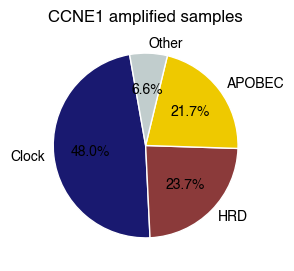

In [14]:
plt.figure(figsize=(3, 3))
sigma[['categ']].join(ccne1_cohort[['ccne1_amp', 'receptor_status']]).query('ccne1_amp == 1').categ.value_counts(normalize=False)\
    .plot.pie(autopct='%1.1f%%',  colors=['#191970', '#8B3A3A', '#EEC900', '#C1CDCD'],  textprops={'fontsize': 10, 'color': 'black'}, wedgeprops={'edgecolor': 'white'}, labels = ['Clock', 'HRD', 'APOBEC', 'Other'],  startangle=100,  counterclock=True)
plt.ylabel('')
plt.title('CCNE1 amplified samples', fontweight='bold')
# plt.savefig('/home/boscoll/Projects/ccne1/results/figures/fig_3/ccne1_amp_signature_pie.pdf', bbox_inches='tight')
plt.show()

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


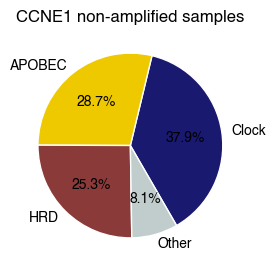

In [20]:
plt.figure(figsize=(3, 3))
sigma[['categ']].join(ccne1_cohort[['ccne1_amp', 'receptor_status']]).query('ccne1_amp == 0').categ.value_counts(normalize=False)\
    .plot.pie(autopct='%1.1f%%',  colors=['#191970',  '#EEC900', '#8B3A3A', '#C1CDCD'],  textprops={'fontsize': 10, 'color': 'black'}, wedgeprops={'edgecolor': 'white'}, labels = ['Clock', 'APOBEC','HRD',  'Other'], startangle=300, counterclock=True)
plt.ylabel('')
plt.title('CCNE1 non-amplified samples', fontweight='bold')
plt.savefig('/home/boscoll/Projects/ccne1/results/figures/fig_3/ccne1_non_amp_signature_pie.pdf', bbox_inches='tight')
plt.show()

***According to receptors subtypes***

In [ ]:
#HR+
(df_stats.query('receptor_status == "HR"').groupby('ccne1_amp').categ.value_counts(normalize=True).unstack() * 100).round(2).astype(str) + '%'

categ,APOBEC,Clock,HRD,Other
ccne1_amp,,,,
0.0,30.95%,41.01%,19.79%,8.24%
1.0,27.69%,46.15%,21.54%,4.62%


In [43]:
%%R -i df_stats
hr_pos = df_stats[df_stats$receptor_status == "HR", ]
fisher.test(table(hr_pos$ccne1_amp, hr_pos$categ))


	Fisher's Exact Test for Count Data

data:  table(hr_pos$ccne1_amp, hr_pos$categ)
p-value = 0.6793
alternative hypothesis: two.sided



In [39]:
#HER2+
(df_stats.query('receptor_status == "HER2"').groupby('ccne1_amp').categ.value_counts(normalize=True).unstack() * 100).round(2).astype(str) + '%'

categ,APOBEC,Clock,HRD,Other
ccne1_amp,,,,
0.0,36.57%,36.41%,20.59%,6.43%
1.0,19.57%,50.0%,23.91%,6.52%


In [66]:
%%R -i df_stats
her2 = df_stats[df_stats$receptor_status == "HER2", ]
fisher.test(table(her2$ccne1_amp, her2$categ))

apobec_ref_her2 = her2
apobec_ref_her2$signature = ifelse(apobec_ref_her2$categ == 'APOBEC', 'APOBEC', 'non-APOBEC')
apobec_ref_her2$signature = factor(apobec_ref_her2$signature, levels=c('non-APOBEC', 'APOBEC'))
print(fisher.test(table(apobec_ref_her2$ccne1_amp, apobec_ref_her2$signature)))
table(apobec_ref_her2$ccne1_amp, apobec_ref_her2$signature)


	Fisher's Exact Test for Count Data

data:  table(apobec_ref_her2$ccne1_amp, apobec_ref_her2$signature)
p-value = 0.0242
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.1758725 0.9120861
sample estimates:
odds ratio 
 0.4223277 

   
    non-APOBEC APOBEC
  0        385    222
  1         37      9


In [49]:
#TNBC
(df_stats.query('receptor_status == "TNBC"').groupby('ccne1_amp').categ.value_counts(normalize=True).unstack() * 100).round(2).astype(str) + '%'

categ,APOBEC,Clock,HRD,Other
ccne1_amp,,,,
0.0,17.23%,29.82%,44.27%,8.67%
1.0,18.39%,48.28%,25.29%,8.05%


In [ ]:
%%R -i df_stats
tnbc = df_stats[df_stats$receptor_status == "TNBC", ]
print(fisher.test(table(tnbc$ccne1_amp, tnbc$categ)))

hrd_ref_tnbc= tnbc
hrd_ref_tnbc$signature = ifelse(tnbc$categ == 'HRD', 'HRD', 'non-HRD')
hrd_ref_tnbc$signature = factor(hrd_ref_tnbc$signature, levels=c('non-HRD', 'HRD'))
print(fisher.test(table(hrd_ref_tnbc$ccne1_amp, hrd_ref_tnbc$signature)))
table(hrd_ref_tnbc$ccne1_amp, hrd_ref_tnbc$signature)


	Fisher's Exact Test for Count Data

data:  table(tnbc$ccne1_amp, tnbc$categ)
p-value = 0.001363
alternative hypothesis: two.sided


	Fisher's Exact Test for Count Data

data:  table(hrd_ref_tnbc$ccne1_amp, hrd_ref_tnbc$signature)
p-value = 0.0006203
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.2460624 0.7142213
sample estimates:
odds ratio 
 0.4263693 

   
    non-HRD HRD
  0     540 429
  1      65  22


# Revision

## TCGA validation

In [178]:
#tsg list 
tsg = pd.read_csv('/scratch/razavip/boscoll/cdk_predict/data/development_cohort/genomics/tsg_list', index_col=0).index.tolist()

#CNA
tcga_cna = pd.read_table('/home/boscoll/Projects/ccne1/data/tcga/data_cna.txt', index_col=0).iloc[:, 1:].T
#merge duplicated columns using the max value
tcga_cna = tcga_cna.T.groupby(level=0, sort=False).max().T 
tcga_cna = tcga_cna.melt(ignore_index=False).assign(cna=lambda x: ['_amp' if i == 2 else '_tsg' if i == -2 else np.nan for i in x['value']]).dropna()\
.assign(Hugo_Symbol = lambda x: x.Hugo_Symbol + x.cna).assign(value=1).drop(columns = 'cna').reset_index().pivot_table(columns='Hugo_Symbol', values='value', index='index').fillna(0)
tcga_cna = tcga_cna[[col for col in alt_matrix.columns if col in tcga_cna.columns]]

#MUT with oncokb annotation
tcga_mut = pd.read_table('/home/boscoll/Projects/ccne1/results/oncokb/data_mutations_oncokb.txt').query('ONCOGENIC in ["Oncogenic", "Likely Oncogenic"]')
tcga_mut = tcga_mut.reset_index().drop_duplicates(subset = ['Tumor_Sample_Barcode', 'Hugo_Symbol'])\
.assign(Hugo_Symbol = lambda x: [i + '_tsg' if i in tsg else i + '_mut' for i in x['Hugo_Symbol']])
tcga_mut = tcga_mut.assign(value = 1).pivot(index='Tumor_Sample_Barcode', columns='Hugo_Symbol', values='value').fillna(0)
tcga_mut = tcga_mut[[col for col in tcga_mut if col in alt_matrix.columns]]

#merge alt matrix
tcga_mat = pd.concat([
    tcga_mut.melt(ignore_index=False), 
    tcga_cna.melt(ignore_index=False)
])\
    .reset_index()\
    .groupby(['index', 'Hugo_Symbol'], as_index=False).max()\
    .pivot(index='index', columns='Hugo_Symbol', values='value')\
    .fillna(0)
tcga_id_ccne1 = tcga_mat.query('CCNE1_amp = =1' ).index


#path variables
tcga_sample = pd.read_table('/home/boscoll/Projects/ccne1/data/tcga/data_clinical_sample.txt', skiprows=4)

#receptor status
tcga_patient = pd.read_table('/home/boscoll/Projects/ccne1/data/tcga/data_clinical_patient.txt', skiprows=4)\
    .merge(tcga_sample[['PATIENT_ID', 'SAMPLE_ID']], left_on = 'PATIENT_ID', right_on = 'PATIENT_ID')\
    .set_index('SAMPLE_ID')[['ER_STATUS_BY_IHC', 'ER_STATUS_IHC_PERCENT_POSITIVE', 'PR_STATUS_BY_IHC', 'PR_STATUS_IHC_PERCENT_POSITIVE', 
                                                                                               'IHC_HER2', 'HER2_FISH_STATUS', 'HISTOLOGICAL_DIAGNOSIS']]
tcga_patient = tcga_patient.assign(receptors = ['HR+/HER2' if ER_STATUS_BY_IHC == 'Positive' and IHC_HER2 != 'Positive' and  HER2_FISH_STATUS != 'Positive' else
                                 'HER2+' if IHC_HER2 == 'Positive' or HER2_FISH_STATUS == 'Positive' else 'TNBC' 
                                 for ER_STATUS_BY_IHC, IHC_HER2, HER2_FISH_STATUS in zip(tcga_patient.ER_STATUS_BY_IHC, tcga_patient.IHC_HER2, tcga_patient.HER2_FISH_STATUS)])
tcga_patient['ccne1_amp'] = [1 if i in tcga_id_ccne1 else 0 for i in tcga_patient.index]

#DFS
dfs = pd.read_table('/home/boscoll/Projects/ccne1/data/tcga/data_clinical_patient.txt', skiprows=4)[['DFS_STATUS', 'DFS_MONTHS', 'PATIENT_ID']]\
.merge(tcga_sample[['PATIENT_ID', 'SAMPLE_ID']], left_on = 'PATIENT_ID', right_on = 'PATIENT_ID')\
    .set_index('SAMPLE_ID')\
.query('DFS_STATUS != "[Not Available]" and DFS_MONTHS != "[Not Available]"')\
 .assign(Event = lambda x: [1 if i =="1:Recurred/Progressed" else 0 for i in x.DFS_STATUS], 
         DFS_MONTHS = lambda x: x.DFS_MONTHS.astype(float),
         Time = lambda x: x.DFS_MONTHS)[['Time', 'Event']]

### Prevalence

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


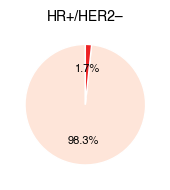

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


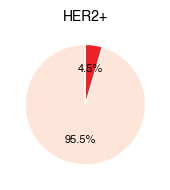

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


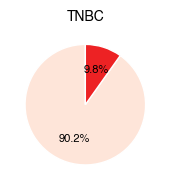

In [221]:
# hr+
pie = tcga_patient.query('receptors == "HR+/HER2"')['ccne1_amp'].value_counts()
plt.figure(figsize=(4, 2))
plt.pie(pie,  colors=['#fee5d9', '#ed2224'], autopct='%.1f%%', startangle=90, textprops={'fontsize': 8}, wedgeprops={'edgecolor': 'white'})
plt.title('HR+/HER2–', fontsize=10)
plt.tight_layout()
plt.savefig('/home/boscoll/Projects/ccne1/results/figures/pie_tcga/pie_hr_pos.pdf')
plt.show()

# her2+
pie = tcga_patient.query('receptors == "HER2+"')['ccne1_amp'].value_counts()
plt.figure(figsize=(4, 2))
plt.pie(pie,  colors=['#fee5d9', '#ed2224'], autopct='%.1f%%', startangle=90, textprops={'fontsize': 8}, wedgeprops={'edgecolor': 'white'})
plt.title('HER2+', fontsize=10)
plt.tight_layout()
plt.savefig('/home/boscoll/Projects/ccne1/results/figures/pie_tcga/pie_her2_pos.pdf')
plt.show()

# tnbc 
pie = tcga_patient.query('receptors == "TNBC"')['ccne1_amp'].value_counts()
plt.figure(figsize=(4, 2))
plt.pie(pie,  colors=['#fee5d9', '#ed2224'], autopct='%.1f%%', startangle=90, textprops={'fontsize': 8}, wedgeprops={'edgecolor': 'white'})
plt.title('TNBC', fontsize=10)
plt.tight_layout()
plt.savefig('/home/boscoll/Projects/ccne1/results/figures/pie_tcga/pie_tnbc.pdf')
plt.show()



In [15]:
%%R -i tcga_patient
chisq.test(table(tcga_patient$receptors, tcga_patient$ccne1_amp))


	Pearson's Chi-squared test

data:  table(tcga_patient$receptors, tcga_patient$ccne1_amp)
X-squared = 31.33, df = 2, p-value = 1.573e-07



### genomic alterations

**Overall**

In [193]:
#logistic regression between alterations using ccne1 amp and corrected for receptors subtype
import statsmodels.api as sm
import warnings 
warnings.filterwarnings("ignore")
res = [] 
for alt in [alt for alt in tcga_mat.columns if alt != 'CCNE1_amp']:
    df_stat = tcga_patient[['ccne1_amp', 'receptors']].join(tcga_mat[[alt]])
    #receptor_status and sample_type as dummies
    df_stat = pd.get_dummies(df_stat, columns=['receptors'], drop_first=True).astype(float)
    df_stat = df_stat.dropna()
    try:
        model = sm.Logit(df_stat[alt], sm.add_constant(df_stat.drop(columns=[alt])))
        result = model.fit(disp=0)
        p_value = result.pvalues['ccne1_amp']
        beta = result.params['ccne1_amp']
        res.append({'gene': alt, 'p_value': p_value, 'beta': beta})
    except:
        res.append({'gene': alt, 'p_value': None, 'beta': None})
res_df = pd.DataFrame(res)
res_df = res_df.dropna()
res_df['fdr'] = fdr_correction(res_df.p_value)
res_df = res_df.sort_values('p_value')
res_df.set_index('gene', inplace=True)
res_df

,p_value,beta,fdr
gene,,,
AKT2_amp,1.856052e-14,3.818429,1.243555e-12
TP53_tsg,8.258033e-04,1.179052,2.766441e-02
AGO2_amp,1.682852e-03,1.050757,3.758369e-02
YES1_amp,2.513202e-03,2.060932,4.209614e-02
MYC_amp,4.362066e-03,0.917865,5.753487e-02
...,...,...,...
CDK4_amp,9.992975e-01,-19.591775,9.999979e-01
TBX3_tsg,9.992984e-01,-19.783604,9.999979e-01
ZFHX3_tsg,9.993262e-01,-20.140440,9.999979e-01


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


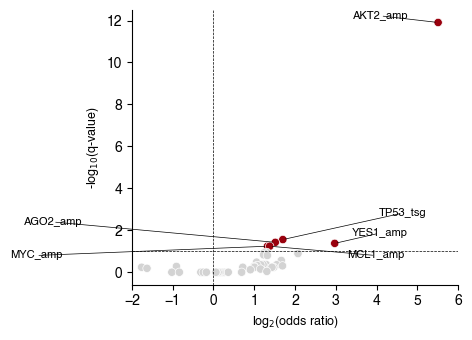

In [204]:
from adjustText import adjust_text
palette = {'positive':'#99000d', 'neutral':'lightgray', 'negative':'#228B22'}
res_df['color'] = ['positive' if fdr < 0.1 else 'neutral' for fdr in res_df.fdr]
res_df['odds_ratio'] = np.exp(res_df.beta)
res_df['log2_or'] = np.log2(res_df.odds_ratio)
res_df['log10_q_value'] = -np.log10(res_df.fdr)
plt.figure(figsize=(5, 3.5))
sns.scatterplot(
    data=res_df,
    x='log2_or',
    y='log10_q_value',
    hue='color',
    palette=palette,
    legend=False
)
text = []
for i in range(res_df.shape[0]):
    if res_df.fdr.iloc[i] < 0.1:
        t = plt.text(res_df.iloc[i]['log2_or'], res_df.iloc[i]['log10_q_value'], res_df.index[i], fontsize=8)
        text.append(t)
adjust_text(text, arrowprops=dict(arrowstyle='-', color='black', lw=0.5), expand_text=(0.5, 0.5),expand_points=(0.5, 0.5), force_text=(0.8, 0.8))
plt.axhline(-np.log10(0.1), color='black', linestyle='--', lw=0.5)
plt.axvline(0, color='black', linestyle='--', lw=0.5)
plt.xlabel('log$_{2}$(odds ratio)', fontsize = 9)
plt.ylabel(f'-log$_{{10}}$(q-value)', fontsize = 9)
plt.xticks(np.arange(-2, 10, 1))
plt.xlim(-2, 6)
# plt.yticks(np.arange(0, 14.1, 2))
mpl.rcParams['pdf.fonttype'] = 42
sns.despine()
plt.tight_layout()
mpl.rcParams['pdf.fonttype'] = 42
plt.savefig('/home/boscoll/Projects/ccne1/results/figures/tcga_volcano.pdf', bbox_inches = 'tight')
plt.show()


**HR+/HER2–**

In [ ]:
#logistic regression between alterations using ccne1 amp and corrected for receptors subtype
import statsmodels.api as sm
import warnings 
warnings.filterwarnings("ignore")
res = [] 
for alt in [alt for alt in tcga_mat.columns if alt != 'CCNE1_amp']:
    df_stat = tcga_patient.query('receptors == "HR+/HER2"')[['ccne1_amp']].join(tcga_mat[[alt]])
    df_stat = df_stat.dropna()
    try:
        model = sm.Logit(df_stat[alt], sm.add_constant(df_stat.drop(columns=[alt])))
        result = model.fit(disp=0)
        p_value = result.pvalues['ccne1_amp']
        beta = result.params['ccne1_amp']
        res.append({'gene': alt, 'p_value': p_value, 'beta': beta})
    except:
        res.append({'gene': alt, 'p_value': None, 'beta': None})
res_df = pd.DataFrame(res)
res_df = res_df.dropna()
res_df['fdr'] = fdr_correction(res_df.p_value)
res_df = res_df.sort_values('p_value')
res_df.set_index('gene', inplace=True)
res_df

,p_value,beta,fdr
gene,,,
AKT2_amp,2.176474e-08,4.493440,0.000002
TP53_tsg,2.603842e-04,2.325686,0.008749
PIK3R1_tsg,3.749456e-04,3.140314,0.008749
AURKA_amp,1.813896e-03,2.205523,0.031743
FGFR1_amp,5.382414e-03,1.717234,0.075354
...,...,...,...
ESR1_mut,9.997147e-01,-17.556842,0.999999
NOTCH1_tsg,9.999991e-01,-0.159448,0.999999
CREBBP_tsg,9.999991e-01,-0.159448,0.999999


**HER2+**

In [79]:
#logistic regression between alterations using ccne1 amp and corrected for receptors subtype
import statsmodels.api as sm
import warnings 
warnings.filterwarnings("ignore")
res = [] 
for alt in [alt for alt in tcga_mat.columns if alt != 'CCNE1_amp']:
    df_stat = tcga_patient.query('receptors != "HR+/HER2"')[['ccne1_amp']].join(tcga_mat[[alt]])
    df_stat = df_stat.dropna()
    try:
        model = sm.Logit(df_stat[alt], sm.add_constant(df_stat.drop(columns=[alt])))
        result = model.fit(disp=0)
        p_value = result.pvalues['ccne1_amp']
        beta = result.params['ccne1_amp']
        res.append({'gene': alt, 'p_value': p_value, 'beta': beta})
    except:
        res.append({'gene': alt, 'p_value': None, 'beta': None})
res_df = pd.DataFrame(res)
res_df = res_df.dropna()
res_df['fdr'] = fdr_correction(res_df.p_value)
res_df = res_df.sort_values('p_value')
res_df.set_index('gene', inplace=True)
res_df

,p_value,beta,fdr
gene,,,
AKT2_amp,1.781579e-09,3.539067,1.247105e-07
YES1_amp,1.055395e-03,2.206125,3.693882e-02
MCL1_amp,1.644142e-03,1.180513,3.836330e-02
AGO2_amp,2.504725e-03,1.131556,4.383269e-02
MYC_amp,3.179786e-03,1.081221,4.451700e-02
...,...,...,...
MEN1_tsg,9.992197e-01,-17.821543,9.999985e-01
SF3B1_mut,9.992362e-01,-17.084165,9.999985e-01
TOP1_tsg,9.992362e-01,-17.084165,9.999985e-01


## Metabric validation

In [34]:
pd.read_table('/home/boscoll/Projects/ccne1/results/metabric_oncokb/data_mutations_oncokb.txt')

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,LEVEL_Dx1,LEVEL_Dx2,LEVEL_Dx3,HIGHEST_DX_LEVEL,DX_CITATIONS,LEVEL_Px1,LEVEL_Px2,LEVEL_Px3,HIGHEST_PX_LEVEL,PX_CITATIONS
0,TP53,NaN,METABRIC,GRCh37,17,7579344,7579345,+,frameshift_variant,Frame_Shift_Ins,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TP53,NaN,METABRIC,GRCh37,17,7579346,7579347,+,protein_altering_variant,In_Frame_Ins,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,MLLT4,NaN,METABRIC,GRCh37,6,168299111,168299111,+,missense_variant,Missense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NF2,NaN,METABRIC,GRCh37,22,29999995,29999995,+,missense_variant,Missense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,SF3B1,NaN,METABRIC,GRCh37,2,198288682,198288682,+,synonymous_variant,Silent,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17267,PIK3CA,NaN,METABRIC,GRCh37,3,178917478,178917478,+,"missense_variant,splice_region_variant",Missense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17268,PIK3CA,NaN,METABRIC,GRCh37,3,178952085,178952085,+,missense_variant,Missense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17269,TP53,NaN,METABRIC,GRCh37,17,7579355,7579355,+,missense_variant,Missense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17270,JAK1,NaN,METABRIC,GRCh37,1,65311232,65311233,+,frameshift_variant,Frame_Shift_Ins,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#tsg list 
tsg = pd.read_csv('/scratch/razavip/boscoll/cdk_predict/data/development_cohort/genomics/tsg_list', index_col=0).index.tolist()

#CNA
metabric_cna = pd.read_table('/home/boscoll/Projects/ccne1/data/metabric/data_cna.txt', index_col=0).iloc[:, 1:].T
#merge duplicated columns using the max value
metabric_cna = metabric_cna.T.groupby(level=0, sort=False).max().T 
metabric_cna = metabric_cna.melt(ignore_index=False).assign(cna=lambda x: ['_amp' if i == 2 else '_tsg' if i == -2 else np.nan for i in x['value']]).dropna()\
.assign(Hugo_Symbol = lambda x: x.Hugo_Symbol + x.cna).assign(value=1).drop(columns = 'cna').reset_index().pivot_table(columns='Hugo_Symbol', values='value', index='index').fillna(0)
metabric_cna = metabric_cna[[col for col in alt_matrix.columns if col in metabric_cna.columns]]

#MUT with oncokb annotation
metabric_mut = pd.read_table('/home/boscoll/Projects/ccne1/results/metabric_oncokb/data_mutations_oncokb.txt').query('ONCOGENIC in ["Oncogenic", "Likely Oncogenic"]')
metabric_mut = metabric_mut.reset_index().drop_duplicates(subset = ['Tumor_Sample_Barcode', 'Hugo_Symbol'])\
.assign(Hugo_Symbol = lambda x: [i + '_tsg' if i in tsg else i + '_mut' for i in x['Hugo_Symbol']])
metabric_mut = metabric_mut.assign(value = 1).pivot(index='Tumor_Sample_Barcode', columns='Hugo_Symbol', values='value').fillna(0)
metabric_mut = metabric_mut[[col for col in metabric_mut if col in alt_matrix.columns]]

#merge alt matrix
metabric_mat = pd.concat([
    metabric_mut.melt(ignore_index=False), 
    metabric_cna.melt(ignore_index=False)
])\
    .reset_index()\
    .groupby(['index', 'Hugo_Symbol'], as_index=False).max()\
    .pivot(index='index', columns='Hugo_Symbol', values='value')\
    .fillna(0)
metabric_id_ccne1 = metabric_mat.query('CCNE1_amp = =1' ).index


#path variables
metabric_sample = pd.read_table('/home/boscoll/Projects/ccne1/data/metabric/data_clinical_sample.txt', skiprows=4, index_col =1)[['CANCER_TYPE_DETAILED', 'ER_STATUS', 'PR_STATUS', 'HER2_STATUS', 'GRADE']]

metabric_sample = metabric_sample.assign(receptors = ['HER2+' if HER2_STATUS == 'Positive' else
                                    'ER+' if ER_STATUS == 'Positive' or PR_STATUS == 'Positive' else
                                     'TNBC'  for ER_STATUS, PR_STATUS, HER2_STATUS in zip(metabric_sample.ER_STATUS, metabric_sample.PR_STATUS, metabric_sample.HER2_STATUS)])
metabric_sample['ccne1_amp'] = [1 if i in metabric_id_ccne1 else 0 for i in metabric_sample.index]


### Prevalence

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


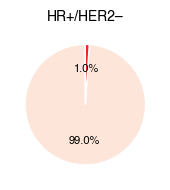

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


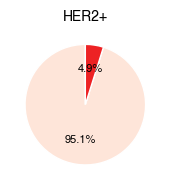

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


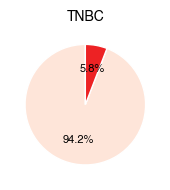

In [220]:
# hr+
pie = metabric_sample.query('receptors == "ER+"')['ccne1_amp'].value_counts()
plt.figure(figsize=(4, 2))
plt.pie(pie,  colors=['#fee5d9', '#ed2224'], autopct='%.1f%%', startangle=90, textprops={'fontsize': 8}, wedgeprops={'edgecolor': 'white'})
plt.title('HR+/HER2–', fontsize=10)
plt.tight_layout()
plt.savefig('/home/boscoll/Projects/ccne1/results/figures/pie_metabric/pie_hr_pos.pdf')
plt.show()

# her2+
pie = metabric_sample.query('receptors == "HER2+"')['ccne1_amp'].value_counts()
plt.figure(figsize=(4, 2))
plt.pie(pie,  colors=['#fee5d9', '#ed2224'], autopct='%.1f%%', startangle=90, textprops={'fontsize': 8}, wedgeprops={'edgecolor': 'white'})
plt.title('HER2+', fontsize=10)
plt.tight_layout()
plt.savefig('/home/boscoll/Projects/ccne1/results/figures/pie_metabric/pie_her2_pos.pdf')
plt.show()

# tnbc 
pie = metabric_sample.query('receptors == "TNBC"')['ccne1_amp'].value_counts()
plt.figure(figsize=(4, 2))
plt.pie(pie,  colors=['#fee5d9', '#ed2224'], autopct='%.1f%%', startangle=90, textprops={'fontsize': 8}, wedgeprops={'edgecolor': 'white'})
plt.title('TNBC', fontsize=10)
plt.tight_layout()
plt.savefig('/home/boscoll/Projects/ccne1/results/figures/pie_metabric/pie_tnbc.pdf')
plt.show()



In [61]:
%%R -i metabric_sample
chisq.test(table(metabric_sample$receptors, metabric_sample$ccne1_amp))


	Pearson's Chi-squared test

data:  table(metabric_sample$receptors, metabric_sample$ccne1_amp)
X-squared = 46.381, df = 2, p-value = 8.484e-11



### Clinicopathologic

**Grade 3**

In [205]:
metabric_sample = metabric_sample.assign(grade_3 = [1 if i == 3 else 0 for i in metabric_sample['GRADE']])

In [217]:
#logistic regression of grade 3 association once correcting for receptors status 
df_stats = metabric_sample.copy()
df_stats = pd.get_dummies(df_stats, columns=['receptors'], drop_first=True)
df_stats[['receptors_HER2+', 'receptors_TNBC']] = df_stats[['receptors_HER2+', 'receptors_TNBC']].astype(int)
model = sm.Logit(df_stats['grade_3'], sm.add_constant(df_stats[['ccne1_amp', 'receptors_HER2+', 'receptors_TNBC']]))
result = model.fit()
print(result.pvalues)

#retrieve odds ratio and 95%CI 
odds_ratios = np.exp(result.params)
conf = np.exp(result.conf_int())
conf.columns = ['2.5%', '97.5%']
odds_ratios_df = pd.concat([odds_ratios, conf], axis=1)
print(odds_ratios_df)

Optimization terminated successfully.
         Current function value: 0.618753
         Iterations 6
const              3.371195e-34
ccne1_amp          5.990896e-04
receptors_HER2+    4.820007e-25
receptors_TNBC     1.018286e-51
dtype: float64
                        0      2.5%     97.5%
const            0.540248  0.489339  0.596453
ccne1_amp        3.529661  1.717644  7.253250
receptors_HER2+  4.858532  3.600248  6.556586
receptors_TNBC   5.636358  4.505226  7.051483


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


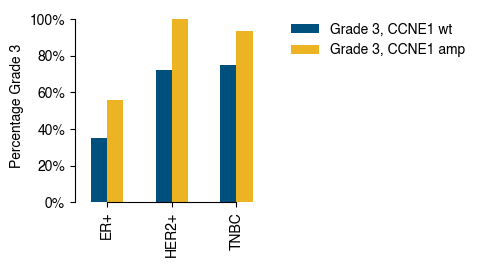

In [218]:
df_plot = metabric_sample.groupby(['receptors', 'ccne1_amp']).grade_3.value_counts(normalize=True).unstack()[[1]].unstack()
df_plot.columns = [['Grade 3, CCNE1 wt', 'Grade 3, CCNE1 amp']]
palette = {'Grade 3, CCNE1 wt':'#00507d', 'Grade 3, CCNE1 amp':'#ecb422'}
# flatten any single-element tuple column names and set explicit labels
df_plot.columns = [c[0] if isinstance(c, tuple) else c for c in df_plot.columns]
df_plot.columns = ['Grade 3, CCNE1 wt', 'Grade 3, CCNE1 amp']
df_plot.plot(kind='bar', color=[palette[col] for col in df_plot.columns], figsize=(2.5, 2.5))
plt.ylabel('Percentage Grade 3')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))
plt.legend(frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine(trim=True, bottom = False)
plt.xlabel('')
plt.savefig('/home/boscoll/Projects/ccne1/results/figures/grade_metabric.pdf')
plt.show()


### genomic alterations

**Overall**

In [187]:
#logistic regression between alterations using ccne1 amp and corrected for receptors subtype
import statsmodels.api as sm
import warnings 
warnings.filterwarnings("ignore")
res = [] 
for alt in [alt for alt in metabric_mat.columns if alt != 'CCNE1_amp']:
    df_stat = metabric_sample[['ccne1_amp', 'receptors']].join(metabric_mat[[alt]])
    #receptor_status and sample_type as dummies
    df_stat = pd.get_dummies(df_stat, columns=['receptors'], drop_first=True).astype(float)
    df_stat = df_stat.dropna()
    try:
        model = sm.Logit(df_stat[alt], sm.add_constant(df_stat.drop(columns=[alt])))
        result = model.fit(disp=0)
        p_value = result.pvalues['ccne1_amp']
        beta = result.params['ccne1_amp']
        res.append({'gene': alt, 'p_value': p_value, 'beta': beta})
    except:
        res.append({'gene': alt, 'p_value': None, 'beta': None})
res_df = pd.DataFrame(res)
res_df = res_df.dropna()
res_df['fdr'] = fdr_correction(res_df.p_value)
res_df = res_df.sort_values('p_value')
res_df.set_index('gene', inplace=True)
res_df

,p_value,beta,fdr
gene,,,
AKT2_amp,1.185332e-13,3.440250,7.111992e-12
TP53_tsg,1.574577e-06,1.839464,4.723731e-05
YES1_amp,9.768286e-06,2.113049,1.953657e-04
NOTCH1_tsg,5.344343e-05,2.209046,8.016514e-04
MYC_amp,2.906989e-04,0.965922,3.488387e-03
FGFR1_amp,1.691502e-03,1.036559,1.519628e-02
NTRK1_amp,1.772900e-03,0.883936,1.519628e-02
ERBB2_amp,3.939567e-03,1.213065,2.954675e-02
AGO2_amp,9.412142e-03,0.725257,6.274761e-02


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


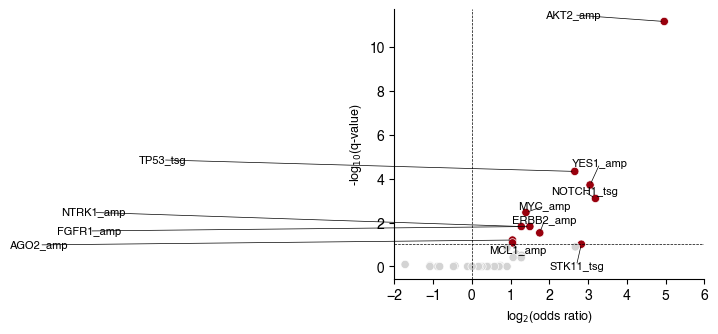

In [192]:
from adjustText import adjust_text
palette = {'positive':'#99000d', 'neutral':'lightgray', 'negative':'#228B22'}
res_df['color'] = ['positive' if fdr < 0.1 else 'neutral' for fdr in res_df.fdr]
res_df['odds_ratio'] = np.exp(res_df.beta)
res_df['log2_or'] = np.log2(res_df.odds_ratio)
res_df['log10_q_value'] = -np.log10(res_df.fdr)
plt.figure(figsize=(4, 3.5))
sns.scatterplot(
    data=res_df,
    x='log2_or',
    y='log10_q_value',
    hue='color',
    palette=palette,
    legend=False
)
text = []
for i in range(res_df.shape[0]):
    if res_df.fdr.iloc[i] < 0.1:
        t = plt.text(res_df.iloc[i]['log2_or'], res_df.iloc[i]['log10_q_value'], res_df.index[i], fontsize=8)
        text.append(t)
adjust_text(text, arrowprops=dict(arrowstyle='-', color='black', lw=0.5), expand_text=(0.5, 0.5),expand_points=(0.5, 0.5), force_text=(0.8, 0.8))
plt.axhline(-np.log10(0.1), color='black', linestyle='--', lw=0.5)
plt.axvline(0, color='black', linestyle='--', lw=0.5)
plt.xlabel('log$_{2}$(odds ratio)', fontsize = 9)
plt.ylabel(f'-log$_{{10}}$(q-value)', fontsize = 9)
plt.xticks(np.arange(-2, 10, 1))
plt.xlim(-2, 6)
# plt.yticks(np.arange(0, 14.1, 2))
mpl.rcParams['pdf.fonttype'] = 42
sns.despine()
plt.tight_layout()
mpl.rcParams['pdf.fonttype'] = 42
plt.savefig('/home/boscoll/Projects/ccne1/results/figures/metabric_volcano.pdf', bbox_inches = 'tight')
plt.show()
